# 📰 News Data: Microsoft MIND — Two-Stage Generate-&-Rerank News Recommendation Engine

The **MIND** dataset is the standard benchmark for neural news recommendation, released by Microsoft Research. It contains ~160 K users, ~65 K articles, and 1 M+ click-through logs collected from MSN News in October 2019.

We replicate the **two-stage generate-and-rerank** paradigm from large-scale recommendation systems:

| Stage | What it does |
|-------|-------------|
| **Stage 1 — Retrieval** | Cast a wide net: merge candidates from popularity, category-affinity, item-CF, and recency signals |
| **Stage 2 — Ranking** | Re-score every candidate with a LightGBM meta-ranker that sees retriever membership, base scores, and rich user/article features |

<a class="anchor" id="top"></a>

---

## 📋 Table of Contents

| # | Section |
|---|---------|
| **1** | [Setup & data loading](#sec-1) |
| **2** | [Exploratory data analysis](#sec-2) |
| **3** | [Feature engineering](#sec-3) |
| **4** | [Article-based collaborative filtering](#sec-4) |
| **5** | [Temporal sequence modelling](#sec-5) |
| **6** | [Evaluation harness & S1–S5 strategies](#sec-6) |
| **7** | [S6 architecture & cold-start gate](#sec-7) |
| **8** | [Stage 1 — Expanded candidate pool](#sec-8) |
| **9** | [Stage 2 — Meta-ranker training](#sec-9) |
| **10** | [Full benchmark: S1 → S7](#sec-10) |
| **11** | [Visualisations](#sec-11) |
| **12** | [Leaderboard & takeaways](#sec-12) |


---

## <a id="sec-1"></a>1. Setup & data loading

### 📖 Dataset & Problem Framing

**What the data is.** MIND-small contains **~1 M impression logs** from 50,000 users over six weeks (Oct 12–Nov 22, 2019). Each impression records a user session: the articles shown, which ones were clicked (label=1) or ignored (label=0), and the user's recent click history.

| File | Key columns | Role |
|------|-------------|------|
| `behaviors.tsv` | `ImpressionId, UserId, Time, History, Impressions` | Primary signal — click/no-click |
| `news.tsv` | `NewsId, Category, SubCategory, Title, Abstract` | Article metadata |

**Task framing.** Given a user's click history, rank candidate news articles so that clicked articles appear at the top. We evaluate with ranking metrics (Precision@K, Recall@K, NDCG@K, Hit-Rate@K).

**Train/test split strategy.** MIND provides an official train split and a dev (validation) split. We use train behaviors for all model fitting and dev behaviors as the held-out test set, preserving the temporal ordering of the original benchmark.

**Implicit feedback.** Unlike star-ratings, every click is a positive signal (label = 1); every article shown but not clicked is a negative (label = 0). We treat clicks as our "liked" items throughout.


In [2]:
# Import libraries
import subprocess, sys

for pkg in ['lightgbm', 'xgboost', 'scikit-learn']:

    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check = True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import zipfile, gc, time, warnings, os, re
from datetime import datetime
from collections import defaultdict, Counter
from scipy.sparse import csr_matrix
from sklearn.preprocessing import normalize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import lightgbm as lgb
from xgboost import XGBClassifier
from joblib import Parallel, delayed
from google.colab import drive
import zipfile

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)

print('✅  Libraries loaded')

✅  Libraries loaded


In [3]:
# Connect to data
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [68]:
# Function to perform parsing
def parse_behaviors_from_zip(zip_path, inner_path):

    with zipfile.ZipFile(zip_path, 'r') as z:

        with z.open(inner_path) as f:

            raw = pd.read_csv(f, sep = '\t', header = None, names = BEH_COLS)

    raw['time'] = pd.to_datetime(raw['time'], format='%m/%d/%Y %I:%M:%S %p')
    raw['ts']   = raw['time'].astype('int64') // 10**9

    rows = []

    # Iterate file
    for _, r in raw.iterrows():

        uid = r['userId']
        ts  = r['ts']

        if pd.notna(r['impressions']):

            for pair in str(r['impressions']).split():

                nid, lbl = pair.rsplit('-', 1)
                rows.append((uid, nid, int(lbl), ts))

    df = pd.DataFrame(rows, columns=['userId','newsId','clicked','timestamp'])

    return df, raw

# Functions to perform metrics analysis
def precision_at_k(recs, true_set, k):

    return len(set(recs[:k]) & true_set) / k if k else 0.0

def recall_at_k(recs, true_set, k):

    return len(set(recs[:k]) & true_set) / len(true_set) if true_set else 0.0

def f1_at_k(recs, true_set, k):

    p = precision_at_k(recs, true_set, k)
    r = recall_at_k(recs, true_set, k)

    return 2*p*r/(p+r) if (p+r) > 0 else 0.0

def ndcg_at_k(recs, true_set, k):

    dcg   = sum(1 / np.log2(i + 2) for i, m in enumerate(recs[:k]) if m in true_set)
    ideal = sum(1 / np.log2(i + 2) for i in range(min(len(true_set), k)))

    return dcg/ideal if ideal else 0.0

def score_recs(recs, true_set, K):

    return {'precision': precision_at_k(recs, true_set, K),
            'recall'   : recall_at_k(recs,    true_set, K),
            'f1'       : f1_at_k(recs,        true_set, K),
            'ndcg'     : ndcg_at_k(recs,      true_set, K),
            'hit_rate' : 1 if any(m in true_set for m in recs[:K]) else 0,}

def evaluate_strategy(score_fn, eval_df, K=10, n=None):

    # score_fn(uid, candidates) -> candidates sorted best-first
    rows = eval_df if n is None else eval_df.sample(n=n, random_state = 100)
    m = {k: [] for k in ('precision','recall','f1','ndcg','hit_rate')}

    for _, row in rows.iterrows():

        recs = score_fn(row['userId'], row['imp_candidates'])
        s    = score_recs(recs, row['true_items'], K)

        for k in m:

            m[k].append(s[k])

    result = {k: float(np.mean(v)) for k, v in m.items()}
    result['composite'] = float(np.mean([result[k] for k in m]))
    return result

metric_keys = ['precision','recall','f1','ndcg','hit_rate']

# Function to parse History field from behaviors to get prior click history length
def parse_history_length(raw_df):

    raw_df = raw_df.copy()
    raw_df['history_len'] = raw_df['history'].fillna('').apply(lambda h: len(str(h).split()) if str(h).strip() else 0)

    return raw_df.groupby('userId')['history_len'].max()

# Function to aggregate daily clisk
def daily_agg(df, split_label):

    tmp = df.copy()
    tmp['date']  = pd.to_datetime(tmp['timestamp'], unit = 's').dt.date

    tmp['split'] = split_label

    return (tmp.groupby(['date', 'split']).agg(impressions = ('clicked', 'count'), clicks = ('clicked', 'sum')).reset_index().assign(ctr = lambda d: d['clicks'] / d['impressions']))

# Functions to implement strategy
def _filter_seen(article_list, uid):

    seen = _seen_cache.get(uid, set())

    return [a for a in article_list if a not in seen]

# Retrieval functions to generate candidates
def s1_popularity(uid, N = 50):

    return _filter_seen(POPULARITY_POOL, uid)[:N]

def s2_category(uid, N = 50):

    if uid not in user_cat_affinity.index:

        return s1_popularity(uid, N)

    uvec = user_cat_affinity.loc[uid].values.astype('float32')
    uvec_n = uvec / (np.linalg.norm(uvec) + 1e-9)
    scores = article_cat_norm @ uvec_n
    ranking = np.argsort(-scores)
    ordered = [article_cat_idx[i] for i in ranking]

    return _filter_seen(ordered, uid)[:N]

def s3_itemcf(uid, N=50):

    clicked = list(user_click_sets.get(uid, []))

    if not clicked:

        return s1_popularity(uid, N)

    score_acc = defaultdict(float)

    for aid in clicked[-20:]:

        for n_aid, sim in item_sim_lookup.get(aid, [])[:30]:

            score_acc[n_aid] += sim

    seen = _seen_cache.get(uid, set())
    ranked = sorted(score_acc.items(), key=lambda x: -x[1])
    filtered = [a for a, _ in ranked if a not in seen]

    if len(filtered) < N:

        filtered += _filter_seen(POPULARITY_POOL, uid)[:N]

    return filtered[:N]

def s4_temporal(uid, N=50):

    if uid not in user_taste_norm.index:

        return s1_popularity(uid, N)

    tvec = user_taste_norm.loc[uid].values.astype('float32')
    scores = article_cat_taste_norm @ tvec
    ranking = np.argsort(-scores)
    ordered = [taste_article_idx[i] for i in ranking]

    return _filter_seen(ordered, uid)[:N]

# ── Impression scorers (used during evaluation) ───────────────────────────────
# Each takes (uid, candidates) and returns candidates ranked best-first.
# Candidates are the articles actually shown to the user in their dev sessions.

def s1_score(uid, candidates):

    return sorted(candidates, key=lambda a: -float(pop_stats.loc[a, 'bayesian_ctr'] if a in pop_stats.index else 0))

def s2_score(uid, candidates):

    if uid not in user_cat_affinity.index:

        return s1_score(uid, candidates)

    uvec = user_cat_affinity.loc[uid].values.astype('float32')
    uvec /= np.linalg.norm(uvec) + 1e-9

    def _s(a):

        art_i = article_cat_idx.index(a) if a in article_cat_idx else -1

        return float(article_cat_norm[art_i] @ uvec) if art_i >= 0 else 0.0

    return sorted(candidates, key=lambda a: -_s(a))

def s3_score(uid, candidates):

    clicked = list(user_click_sets.get(uid, []))

    if not clicked:

        return s1_score(uid, candidates)

    score_acc = defaultdict(float)

    for aid in clicked[-20:]:

        for n_aid, sim in item_sim_lookup.get(aid, [])[:30]:

            score_acc[n_aid] += sim

    return sorted(candidates, key=lambda a: -score_acc.get(a, 0))

def s4_score(uid, candidates):

    if uid not in user_taste_norm.index:

        return s1_score(uid, candidates)

    tvec = user_taste_norm.loc[uid].values.astype('float32')

    def _s(a):

        i = taste_article_idx.index(a) if a in taste_article_idx else -1

        return float(article_cat_taste_norm[i] @ tvec) if i >= 0 else 0.0

    return sorted(candidates, key=lambda a: -_s(a))

def s5_score(uid, candidates):

    if uid in user_cat_affinity.index:

        uvec = user_cat_affinity.loc[uid].values.astype('float32')
        uvec /= np.linalg.norm(uvec) + 1e-9
        s2_vec = article_cat_norm @ uvec

    else:

        s2_vec = np.zeros(len(article_cat_idx))

    if uid in user_taste_norm.index:

        tvec = user_taste_norm.loc[uid].values.astype('float32')
        s4_vec = article_cat_taste_norm @ tvec

    else:

        s4_vec = np.zeros(len(taste_article_idx))

    s2_d = {i: float(s2_vec[i]) for i in range(len(article_cat_idx))}
    s4_d = {i: float(s4_vec[i]) for i in range(len(taste_article_idx))}
    rows = [_build_feature_row(uid, a, s2_d, s4_d) for a in candidates]
    X    = np.array(rows, dtype='float32')
    probs = lgb_model.predict(X)

    return [candidates[i] for i in np.argsort(-probs)]

def s6_score(uid, candidates):

    if is_cold(uid):

        return s1_score(uid, candidates)

    if uid in user_cat_affinity.index:

        uvec  = user_cat_affinity.loc[uid].values.astype('float32')
        s2_vec = article_cat_norm @ (uvec / (np.linalg.norm(uvec) + 1e-9))

    else:

        s2_vec = np.zeros(len(article_cat_idx))

    if uid in user_taste_norm.index:

        tvec  = user_taste_norm.loc[uid].values.astype('float32')
        s4_vec = article_cat_taste_norm @ tvec

    else:

        s4_vec = np.zeros(len(taste_article_idx))

    X_base = np.array([[
        float(user_stats.loc[uid,'click_count']) if uid in user_stats.index else 0,
        float(user_stats.loc[uid,'click_freq'])  if uid in user_stats.index else 0,
        float(article_feat.loc[a,'log_clicks'])   if a in article_feat.index else 0,
        float(article_feat.loc[a,'log_impr'])     if a in article_feat.index else 0,
        float(article_feat.loc[a,'bayesian_ctr']) if a in article_feat.index else 0,
        float(article_feat.loc[a,'article_len'])  if a in article_feat.index else 0,
        float(s2_vec[article_cat_idx.index(a)]) if a in article_cat_idx else 0,
        float(s4_vec[taste_article_idx.index(a)]) if a in taste_article_idx else 0,] for a in candidates], dtype='float32')

    base_scores = lgb_model.predict(X_base)
    cands_s2 = s2_category(uid, N_STAGE1)
    cands_s3 = s3_itemcf(uid, N_STAGE1)
    cands_s4 = s4_temporal(uid, N_STAGE1)
    X_meta = _build_meta_features(uid, candidates, cands_s2, cands_s3, cands_s4, s2_vec, s4_vec, base_scores)
    scores = meta_lgb.predict(X_meta)

    return [candidates[i] for i in np.argsort(-scores)]

def s7_score(uid, candidates):

    if is_cold(uid):

        return s1_score(uid, candidates)

    if uid in user_cat_affinity.index:

        uvec  = user_cat_affinity.loc[uid].values.astype('float32')
        s2_vec = article_cat_norm @ (uvec / (np.linalg.norm(uvec) + 1e-9))

    else:

        s2_vec = np.zeros(len(article_cat_idx))

    if uid in user_taste_norm.index:

        tvec  = user_taste_norm.loc[uid].values.astype('float32')
        s4_vec = article_cat_taste_norm @ tvec

    else:

        s4_vec = np.zeros(len(taste_article_idx))

    X_base = np.array([[
        float(user_stats.loc[uid,'click_count']) if uid in user_stats.index else 0,
        float(user_stats.loc[uid,'click_freq'])  if uid in user_stats.index else 0,
        float(article_feat.loc[a,'log_clicks'])   if a in article_feat.index else 0,
        float(article_feat.loc[a,'log_impr'])     if a in article_feat.index else 0,
        float(article_feat.loc[a,'bayesian_ctr']) if a in article_feat.index else 0,
        float(article_feat.loc[a,'article_len'])  if a in article_feat.index else 0,
        float(s2_vec[article_cat_idx.index(a)]) if a in article_cat_idx else 0,
        float(s4_vec[taste_article_idx.index(a)]) if a in taste_article_idx else 0,
    ] for a in candidates], dtype='float32')

    base_scores = lgb_model.predict(X_base)
    cands_s2 = s2_category(uid, N_STAGE1)
    cands_s3 = s3_itemcf(uid, N_STAGE1)
    cands_s4 = s4_temporal(uid, N_STAGE1)
    X_meta = _build_meta_features(uid, candidates, cands_s2, cands_s3, cands_s4, s2_vec, s4_vec, base_scores)
    lgb_probs = meta_lgb.predict(X_meta)
    xgb_probs = xgb_meta.predict_proba(X_meta)[:, 1]
    scores    = 0.6 * lgb_probs + 0.4 * xgb_probs
    return [candidates[i] for i in np.argsort(-scores)]

def _build_feature_row(uid, aid, s2_scores_dict, s4_scores_dict):

    us  = user_stats.loc[uid]  if uid in user_stats.index  else None
    af  = article_feat.loc[aid] if aid in article_feat.index else None
    art_i  = art_pos.get(aid, -1)
    tst_i  = taste_pos.get(aid, -1)
    cat_aff = float(s2_scores_dict.get(art_i, 0))
    tst_aff = float(s4_scores_dict.get(tst_i, 0))

    return [
        float(us['click_count'])   if us is not None else 0,
        float(us['click_freq'])    if us is not None else 0,
        float(af['log_clicks'])    if af is not None else 0,
        float(af['log_impr'])      if af is not None else 0,
        float(af['bayesian_ctr'])  if af is not None else 0,
        float(af['article_len'])     if af is not None else 0,
        cat_aff, tst_aff,]

def s5_lgb(uid, N = 50, _s2 = None, _s4 = None):

    candidates = list(dict.fromkeys(s2_category(uid, K_CAND) + s3_itemcf(uid, K_CAND) + s4_temporal(uid, K_CAND)))[:K_CAND]

    if not candidates:

        return s1_popularity(uid, N)

    if uid in user_cat_affinity.index:

        uvec = user_cat_affinity.loc[uid].values.astype('float32')
        uvec /= np.linalg.norm(uvec) + 1e-9
        s2_vec = article_cat_norm @ uvec

    else:

        s2_vec = np.zeros(len(article_cat_idx))

    if uid in user_taste_norm.index:

        tvec = user_taste_norm.loc[uid].values.astype('float32')
        s4_vec = article_cat_taste_norm @ tvec

    else:

        s4_vec = np.zeros(len(taste_article_idx))

    s2_d = {i: float(s2_vec[i]) for i in range(len(article_cat_idx))}
    s4_d = {i: float(s4_vec[i]) for i in range(len(taste_article_idx))}

    rows = [_build_feature_row(uid, aid, s2_d, s4_d) for aid in candidates]
    X    = np.array(rows, dtype='float32')
    probs = lgb_model.predict(X)
    order = np.argsort(-probs)
    return [candidates[i] for i in order][:N]

def _build_meta_features(uid, candidates, cands_s2, cands_s3, cands_s4, s2_vec, s4_vec, lgb_base_scores):

    s2_rank = {a: r for r, a in enumerate(cands_s2)}
    s3_rank = {a: r for r, a in enumerate(cands_s3)}
    s4_rank = {a: r for r, a in enumerate(cands_s4)}

    rows = []

    for k, aid in enumerate(candidates):

        us  = user_stats.loc[uid]  if uid in user_stats.index  else None
        af  = article_feat.loc[aid] if aid in article_feat.index else None
        art_i   = article_cat_idx.index(aid) if aid in article_cat_idx else -1
        cat_aff = float(s2_vec[art_i]) if art_i >= 0 else 0.0
        tst_aff = float(s4_vec[art_i]) if art_i >= 0 else 0.0

        rows.append([
            float(us['click_count'])   if us is not None else 0,
            float(us['click_freq'])    if us is not None else 0,
            float(af['log_clicks'])    if af is not None else 0,
            float(af['log_impr'])      if af is not None else 0,
            float(af['bayesian_ctr'])  if af is not None else 0,
            float(af['article_len'])     if af is not None else 0,
            cat_aff, tst_aff,
            int(aid in s2_rank), int(aid in s3_rank), int(aid in s4_rank),
            s2_rank.get(aid, N_STAGE1), s3_rank.get(aid, N_STAGE1),
            s4_rank.get(aid, N_STAGE1),
            int(aid in s2_rank) + int(aid in s3_rank) + int(aid in s4_rank),
            float(lgb_base_scores[k]),
        ])
    return np.array(rows, dtype='float32')

def s6_meta_lgb(uid, N=50):

    if is_cold(uid):

        return s1_popularity(uid, N)

    cands_s2 = s2_category(uid, N_STAGE1)
    cands_s3 = s3_itemcf(uid, N_STAGE1)
    cands_s4 = s4_temporal(uid, N_STAGE1)
    candidates = list(dict.fromkeys(cands_s2 + cands_s3 + cands_s4))[:N_STAGE1]

    if uid in user_cat_affinity.index:

        uvec  = user_cat_affinity.loc[uid].values.astype('float32')
        s2_vec = article_cat_norm @ (uvec / (np.linalg.norm(uvec)+1e-9))

    else:

        s2_vec = np.zeros(len(article_cat_idx))

    if uid in user_taste_norm.index:

        tvec  = user_taste_norm.loc[uid].values.astype('float32')
        s4_vec = article_cat_taste_norm @ tvec

    else:

        s4_vec = np.zeros(len(taste_article_idx))

    X_base  = np.array([[float(user_stats.loc[uid,'click_count']) if uid in user_stats.index else 0,
                        float(user_stats.loc[uid,'click_freq'])  if uid in user_stats.index else 0,
                        float(article_feat.loc[a,'log_clicks'])   if a in article_feat.index else 0,
                        float(article_feat.loc[a,'log_impr'])     if a in article_feat.index else 0,
                        float(article_feat.loc[a,'bayesian_ctr']) if a in article_feat.index else 0,
                        float(article_feat.loc[a,'article_len'])    if a in article_feat.index else 0,
                        float(s2_vec[article_cat_idx.index(a)]) if a in article_cat_idx else 0,
                        float(s4_vec[taste_article_idx.index(a)]) if a in taste_article_idx else 0,] for a in candidates], dtype='float32')

    base_scores = lgb_model.predict(X_base)
    X_meta = _build_meta_features(uid, candidates, cands_s2, cands_s3, cands_s4, s2_vec, s4_vec, base_scores)
    scores  = meta_lgb.predict(X_meta)
    order   = np.argsort(-scores)
    return [candidates[i] for i in order][:N]

def s7_ensemble(uid, N=50):

    """S7: average meta-LGB and meta-XGB probabilities."""
    if is_cold(uid):
        return s1_popularity(uid, N)
    cands_s2 = s2_category(uid, N_STAGE1)
    cands_s3 = s3_itemcf(uid, N_STAGE1)
    cands_s4 = s4_temporal(uid, N_STAGE1)
    candidates = list(dict.fromkeys(cands_s2 + cands_s3 + cands_s4))[:N_STAGE1]

    if uid in user_cat_affinity.index:
        uvec  = user_cat_affinity.loc[uid].values.astype('float32')
        s2_vec = article_cat_norm @ (uvec / (np.linalg.norm(uvec)+1e-9))
    else: s2_vec = np.zeros(len(article_cat_idx))

    if uid in user_taste_norm.index:
        tvec  = user_taste_norm.loc[uid].values.astype('float32')
        s4_vec = article_cat_taste_norm @ tvec
    else: s4_vec = np.zeros(len(taste_article_idx))

    X_base = np.array([[
        float(user_stats.loc[uid,'click_count']) if uid in user_stats.index else 0,
        float(user_stats.loc[uid,'click_freq'])  if uid in user_stats.index else 0,
        float(article_feat.loc[a,'log_clicks'])   if a in article_feat.index else 0,
        float(article_feat.loc[a,'log_impr'])     if a in article_feat.index else 0,
        float(article_feat.loc[a,'bayesian_ctr']) if a in article_feat.index else 0,
        float(article_feat.loc[a,'article_len'])    if a in article_feat.index else 0,
        float(s2_vec[article_cat_idx.index(a)]) if a in article_cat_idx else 0,
        float(s4_vec[taste_article_idx.index(a)]) if a in taste_article_idx else 0,
    ] for a in candidates], dtype='float32')

    base_scores = lgb_model.predict(X_base)
    X_meta = _build_meta_features(uid, candidates, cands_s2, cands_s3, cands_s4,
                                   s2_vec, s4_vec, base_scores)
    lgb_probs = meta_lgb.predict(X_meta)
    xgb_probs = xgb_meta.predict_proba(X_meta)[:, 1]
    scores    = 0.6 * lgb_probs + 0.4 * xgb_probs
    order     = np.argsort(-scores)
    return [candidates[i] for i in order][:N]

COLD_THRESHOLD = 2

def is_cold(uid):

    if uid not in user_stats.index: return True
    return user_stats.loc[uid, 'click_count'] < COLD_THRESHOLD

# Raw retrievers — no seen filter so clicked articles stay in the pool
def _raw_s2(uid, N):

    if uid not in user_cat_affinity.index:

        return POPULARITY_POOL[:N]

    uvec = user_cat_affinity.loc[uid].values.astype('float32')
    uvec = uvec / (np.linalg.norm(uvec) + 1e-9)

    return [article_cat_idx[j] for j in np.argsort(-(article_cat_norm @ uvec))[:N]]

def _raw_s3(uid, N):

    clicked = list(user_click_sets.get(uid, []))

    if not clicked:

        return POPULARITY_POOL[:N]

    score_acc = defaultdict(float)

    for aid in clicked[-20:]:

        for n_aid, sim in item_sim_lookup.get(aid, [])[:30]:

            score_acc[n_aid] += sim

    ranked = [a for a, _ in sorted(score_acc.items(), key=lambda x: -x[1])]

    return (ranked + POPULARITY_POOL)[:N]

def _raw_s4(uid, N):

    if uid not in user_taste_norm.index:

        return POPULARITY_POOL[:N]

    tvec = user_taste_norm.loc[uid].values.astype('float32')

    return [taste_article_idx[j] for j in np.argsort(-(article_cat_taste_norm @ tvec))[:N]]

# chunked_topn must be defined here, in the same cell that calls it,
# so the closure over n_users / unique_users / CHUNK_SIZE is always fresh.
def chunked_topn(A_norm, U_mat, article_idx_arr, n_top, rank_col):

    """
    Top-n retrieval via chunked matmul.
    Peak RAM = n_articles × CHUNK_SIZE × 4 bytes instead of n_articles × n_users × 4 bytes.
    """
    parts = []

    for start in range(0, n_users, CHUNK_SIZE):

        end       = min(start + CHUNK_SIZE, n_users)
        u_batch   = unique_users[start:end]
        scores    = A_norm @ U_mat[start:end].T        # [n_articles, chunk]
        top_idx   = np.argsort(-scores, axis=0)[:n_top]  # [n_top, chunk]
        chunk_len = end - start
        parts.append(pd.DataFrame({
            'userId': np.repeat(u_batch, n_top),
            'newsId': article_idx_arr[top_idx.T.ravel()],
            rank_col: np.tile(np.arange(n_top), chunk_len),
        }))
        del scores, top_idx
    gc.collect()
    return pd.concat(parts, ignore_index=True)

In [5]:
# Load the data
TRAIN_ZIP = 'drive/MyDrive/MINDsmall_train.zip'
DEV_ZIP   = 'drive/MyDrive/MINDsmall_dev.zip'

# Quick sanity-check: list contents of each archive
for label, path in [('TRAIN', TRAIN_ZIP), ('DEV', DEV_ZIP)]:

    with zipfile.ZipFile(path, 'r') as z:

        print(f'{label} ZIP contents: {z.namelist()}')

TRAIN ZIP contents: ['MINDsmall_train/', 'MINDsmall_train/behaviors.tsv', 'MINDsmall_train/news.tsv', 'MINDsmall_train/entity_embedding.vec', 'MINDsmall_train/relation_embedding.vec']
DEV ZIP contents: ['MINDsmall_dev/', 'MINDsmall_dev/behaviors.tsv', 'MINDsmall_dev/news.tsv', 'MINDsmall_dev/entity_embedding.vec', 'MINDsmall_dev/relation_embedding.vec']


In [6]:
# Define columns of interest
NEWS_COLS = ['newsId','category','subCategory','title','abstract','url', 'titleEntities','abstractEntities']
BEH_COLS = ['impressionId', 'userId', 'time', 'history', 'impressions']

print('Loading train news...', end=' ', flush = True)

# Load the data from file
with zipfile.ZipFile(TRAIN_ZIP, 'r') as z:

    with z.open('MINDsmall_train/news.tsv') as f:

        news_train = pd.read_csv(f, sep = '\t', header = None, names = NEWS_COLS, usecols = ['newsId', 'category', 'subCategory', 'title', 'abstract'])

print(f'done  ({len(news_train):,} articles)')

print('Loading dev news...  ', end = ' ', flush = True)

# Load the data from file
with zipfile.ZipFile(DEV_ZIP, 'r') as z:

    with z.open('MINDsmall_dev/news.tsv') as f:

        news_dev = pd.read_csv(f, sep = '\t', header = None, names = NEWS_COLS, usecols = ['newsId','category','subCategory','title','abstract'])

print(f'done  ({len(news_dev):,} articles)')

Loading train news... done  (51,282 articles)
Loading dev news...   done  (42,416 articles)


In [7]:
# Merge ther files together
news = pd.concat([news_train, news_dev]).drop_duplicates('newsId').reset_index(drop = True)

# Fill empty cells
news['abstract'] = news['abstract'].fillna('')
news['text']     = news['title'] + ' ' + news['abstract']

print(f'\nUnique articles : {len(news):,}')
print(f'Categories      : {news["category"].nunique()}')
print(f'Sub-categories  : {news["subCategory"].nunique()}')
news.head()


Unique articles : 65,238
Categories      : 18
Sub-categories  : 270


,newsId,category,subCategory,title,abstract,text
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...","The Brands Queen Elizabeth, Prince Charles, an..."
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,50 Worst Habits For Belly Fat These seemingly ...
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,The Cost of Trump's Aid Freeze in the Trenches...
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",I Was An NBA Wife. Here's How It Affected My M...
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...","How to Get Rid of Skin Tags, According to a De..."


In [8]:
# Expand each impression list into one row per (user, article, label) from the behavioral data
print('Parsing train behaviors...', end = ' ', flush = True)
interactions_train, raw_train = parse_behaviors_from_zip(TRAIN_ZIP, 'MINDsmall_train/behaviors.tsv')
print(f'done  ({len(interactions_train):,} rows)')

print('Parsing dev behaviors...  ', end = ' ', flush = True)
interactions_dev, raw_dev = parse_behaviors_from_zip(DEV_ZIP, 'MINDsmall_dev/behaviors.tsv')
print(f'done  ({len(interactions_dev):,} rows)')

# Tag splits and combine
interactions_train['split'] = 'train'
interactions_dev['split']   = 'dev'

all_interactions = pd.concat([interactions_train, interactions_dev], ignore_index = True)

print(f'\nTotal interactions : {len(all_interactions):,}')
print(f'  Train            : {len(interactions_train):,}')
print(f'  Dev              : {len(interactions_dev):,}')

Parsing train behaviors... done  (5,843,444 rows)
Parsing dev behaviors...   done  (2,740,998 rows)

Total interactions : 8,584,442
  Train            : 5,843,444
  Dev              : 2,740,998


In [9]:
all_interactions.head()

,userId,newsId,clicked,timestamp,split
0,U13740,N55689,1,1573463158,train
1,U13740,N35729,0,1573463158,train
2,U91836,N20678,0,1573582290,train
3,U91836,N39317,0,1573582290,train
4,U91836,N58114,0,1573582290,train


In [10]:
all_interactions['split'].value_counts()

,count
split,
train,5843444
dev,2740998


In [11]:
all_interactions['userId'].nunique()

94057

In [12]:
# Split the data for training
train_clicks = interactions_train[interactions_train['clicked'] == 1]
train_clicks['newsId'] = train_clicks['newsId'].astype(str)

test_clicks = interactions_dev[interactions_dev['clicked'] == 1]
test_clicks['newsId'] = test_clicks['newsId'].astype(str)

In [13]:
# Compile the ground truths
_seen_cache = train_clicks.groupby('userId')['newsId'].apply(set).to_dict()
ground_truth = (test_clicks.groupby('userId')['newsId'].apply(set).rename('true_items'))

In [14]:
# Gather the users
train_users   = set(train_clicks['userId'].unique())
test_users    = set(ground_truth.index)
warm_users    = train_users & test_users
cold_users    = test_users - train_users

print(f'Train positive clicks  : {len(train_clicks):,}')
print(f'Dev   positive clicks  : {len(test_clicks):,}')
print(f'Unique train users     : {len(train_users):,}')
print(f'Unique test  users     : {len(test_users):,}')
print(f'Warm users (train test): {len(warm_users):,}')
print(f'Cold users (test only) : {len(cold_users):,}')

Train positive clicks  : 236,344
Dev   positive clicks  : 111,383
Unique train users     : 50,000
Unique test  users     : 50,000
Warm users (train test): 5,943
Cold users (test only) : 44,057


In [15]:
# Parse raw_dev to get per-user impression candidates and ground truth clicks.
# Each dev session shows a user a small set of candidate articles (5–30);
# evaluation must rank within those candidates, not across all 65K articles.
dev_imp = raw_dev

dev_imp['cands']   = dev_imp['impressions'].apply(lambda x: [p.split('-')[0] for p in str(x).split()] if pd.notna(x) else [])
dev_imp['clicked'] = dev_imp['impressions'].apply(lambda x: [p.split('-')[0] for p in str(x).split() if p.endswith('-1')] if pd.notna(x) else [])

user_dev = (dev_imp.groupby('userId').agg(imp_candidates=('cands',   lambda x: list(dict.fromkeys(a for lst in x for a in lst))), true_items = ('clicked', lambda x: set(a for lst in x for a in lst))).reset_index())

eval_df  = user_dev[user_dev['userId'].isin(warm_users) & user_dev['true_items'].apply(len).gt(0)].reset_index(drop = True)

eval_warm = eval_df

print(f'Eval users (warm, ≥1 GT)    : {len(eval_warm):,}')
print(f'Avg impression candidates/user: {eval_warm["imp_candidates"].apply(len).mean():.1f}')
eval_warm.head()

Eval users (warm, ≥1 GT)    : 5,943
Avg impression candidates/user: 50.5


,userId,imp_candidates,true_items
0,U10008,"[N55237, N50775, N5472, N58251, N62365, N49285...",{N31958}
1,U10012,"[N29862, N28640, N512, N60762, N52492, N25673,...","{N12409, N46162, N6916, N56969}"
2,U10044,"[N40656, N31958, N5940, N53283, N36940, N48487...","{N6638, N36779}"
3,U10045,"[N29862, N19990, N38620, N1952, N15347, N55036...","{N19611, N21681}"
4,U10050,"[N32708, N45586, N21142, N51797, N39151, N1385...",{N21142}


In [16]:
# Count clicks per article across the training split
pop_counts = train_clicks.groupby('newsId')['clicked'].count().rename('click_count')

# Bayesian-smoothed score: (clicks + C*global_rate) / (impressions + C)
total_impressions = interactions_train.groupby('newsId')['clicked'].count().rename('impressions')

# Global click-through rate
GLOBAL_CTR = train_clicks.shape[0] / len(interactions_train)

# Smoothing constant
C = 50

pop_stats = (pop_counts.to_frame().join(total_impressions).fillna(0))
pop_stats['bayesian_ctr'] = ((pop_stats['click_count'] + C * GLOBAL_CTR) / (pop_stats['impressions'] + C)).astype('float32')

# Articles ranked by training CTR
#train_ranked = pop_stats.sort_values('bayesian_ctr', ascending=False).index.tolist()

# Dev articles not seen in training are appended so they are still reachable by every retriever
#train_pool_set  = set(train_ranked)
#unseen_articles = [a for a in news['newsId'].astype(str) if a not in train_pool_set]
#POPULARITY_POOL = train_ranked + unseen_articles

POPULARITY_POOL = pop_stats.sort_values('bayesian_ctr', ascending = False).index.tolist()

print(f'Popularity pool  : {len(POPULARITY_POOL):,} training articles')
print(f'Global CTR       : {GLOBAL_CTR:.4f}')
pop_stats.sort_values('impressions', ascending=False).head(6)

Popularity pool  : 7,713 training articles
Global CTR       : 0.0404


,click_count,impressions,bayesian_ctr
newsId,,,
N47061,820,23037,0.0356
N51048,1875,19242,0.0973
N26262,1139,19106,0.0596
N50872,279,18702,0.0150
N55689,4316,18315,0.2351
N38779,1490,18101,0.0822


[Back to top](#top)

---

## <a id="sec-2"></a>2. Exploratory data analysis

### 📖 Understanding the data before modelling

This section answers eight key questions before building any model:

1. How are clicks distributed across articles? (power law expected)
2. How active are individual users?
3. Which categories dominate the corpus?
4. How does CTR vary by category?
5. What is the article title-length distribution?
6. How do click volumes trend over time?
7. What fraction of users have very thin histories (cold-start risk)?
8. How much overlap exists between train and dev article pools?


In [17]:
# Compile high-level stats
n_users   = all_interactions['userId'].nunique()
n_articles= all_interactions['newsId'].nunique()
n_impr    = len(all_interactions)
n_clicks  = all_interactions['clicked'].sum()
overall_ctr = n_clicks / n_impr

print(f'{"Users":<30} {n_users:>10,}')
print(f'{"Articles":<30} {n_articles:>10,}')
print(f'{"Total impressions":<30} {n_impr:>10,}')
print(f'{"Total clicks":<30} {n_clicks:>10,}')
print(f'{"Overall CTR":<30} {overall_ctr:>10.4f}')
print(f'{"Sparsity":<30} {1 - n_clicks/(n_users*n_articles):>10.6f}')

Users                              94,057
Articles                           22,771
Total impressions               8,584,442
Total clicks                      347,727
Overall CTR                        0.0405
Sparsity                         0.999838


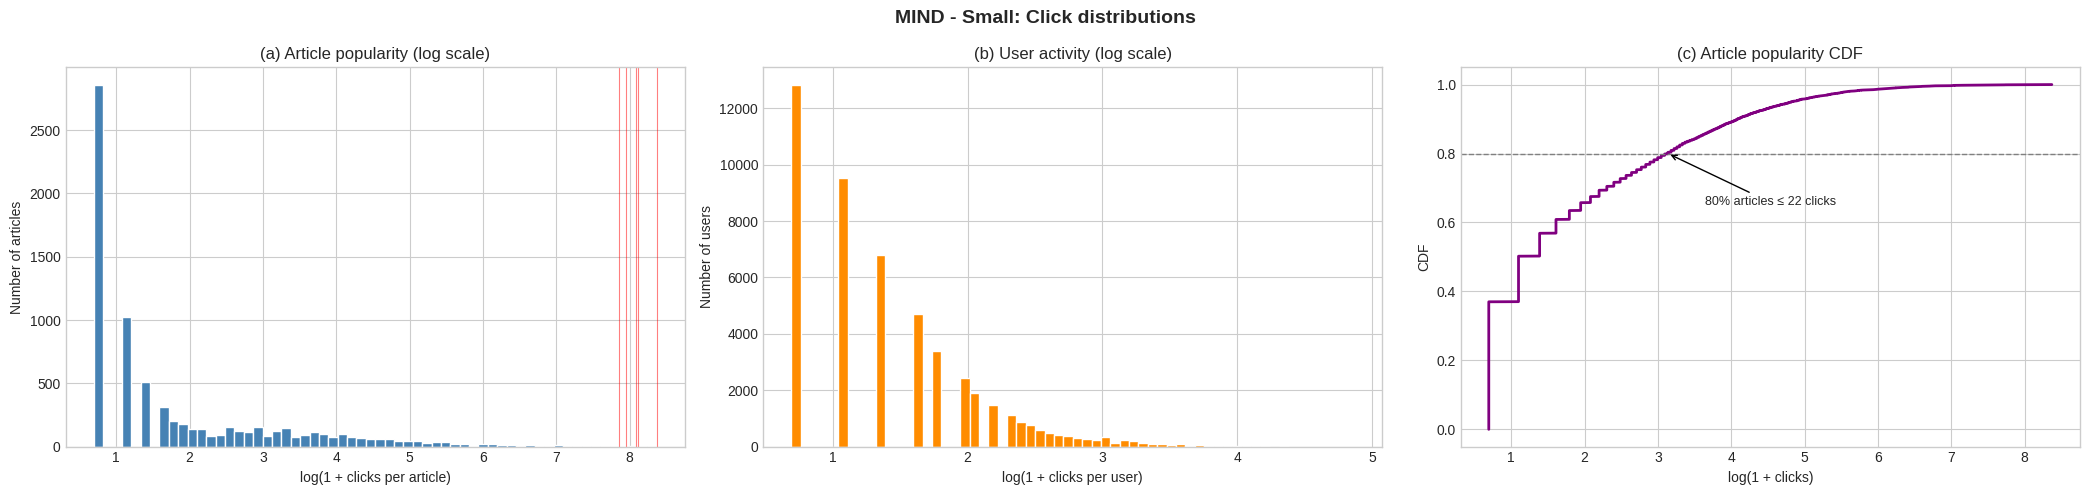

In [18]:
# Compile the clicks distribution and user activity
article_clicks = train_clicks.groupby('newsId')['clicked'].count()
user_clicks    = train_clicks.groupby('userId')['clicked'].count()

fig, axes = plt.subplots(1, 3, figsize=(21, 5))
fig.suptitle('MIND - Small: Click distributions', fontsize = 14, fontweight = 'bold')

# (a) Article click histogram (log scale)
ax = axes[0]
ax.hist(np.log1p(article_clicks.values), bins = 60, color = 'steelblue', edgecolor = 'white', lw = 0.4)
ax.set_xlabel('log(1 + clicks per article)')
ax.set_ylabel('Number of articles')
ax.set_title('(a) Article popularity (log scale)')
top5 = article_clicks.nlargest(5)

# Iterate
for nid, cnt in top5.items():

    title = news.set_index('newsId').loc[nid, 'title'] if nid in news['newsId'].values else nid
    ax.axvline(np.log1p(cnt), color='red', lw=0.8, alpha=0.5)

# (b) User activity histogram
ax = axes[1]
ax.hist(np.log1p(user_clicks.values), bins=60, color='darkorange', edgecolor='white', lw=0.4)
ax.set_xlabel('log(1 + clicks per user)')
ax.set_ylabel('Number of users')
ax.set_title('(b) User activity (log scale)')

# (c) Click count CDF for articles
ax = axes[2]
sorted_clicks = np.sort(article_clicks.values)
cdf = np.arange(1, len(sorted_clicks)+1) / len(sorted_clicks)
ax.plot(np.log1p(sorted_clicks), cdf, color='purple', lw=2)
ax.axhline(0.8, color='grey', ls='--', lw=1)
ax.set_xlabel('log(1 + clicks)')
ax.set_ylabel('CDF')
ax.set_title('(c) Article popularity CDF')

# Find where 80% of articles have fewer than X clicks
p80_idx = np.searchsorted(cdf, 0.8)
ax.annotate(f'80% articles ≤ {sorted_clicks[p80_idx]} clicks',
            xy=(np.log1p(sorted_clicks[p80_idx]), 0.8),
            xytext=(np.log1p(sorted_clicks[p80_idx])+0.5, 0.65),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

plt.tight_layout()
plt.savefig('eda_click_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

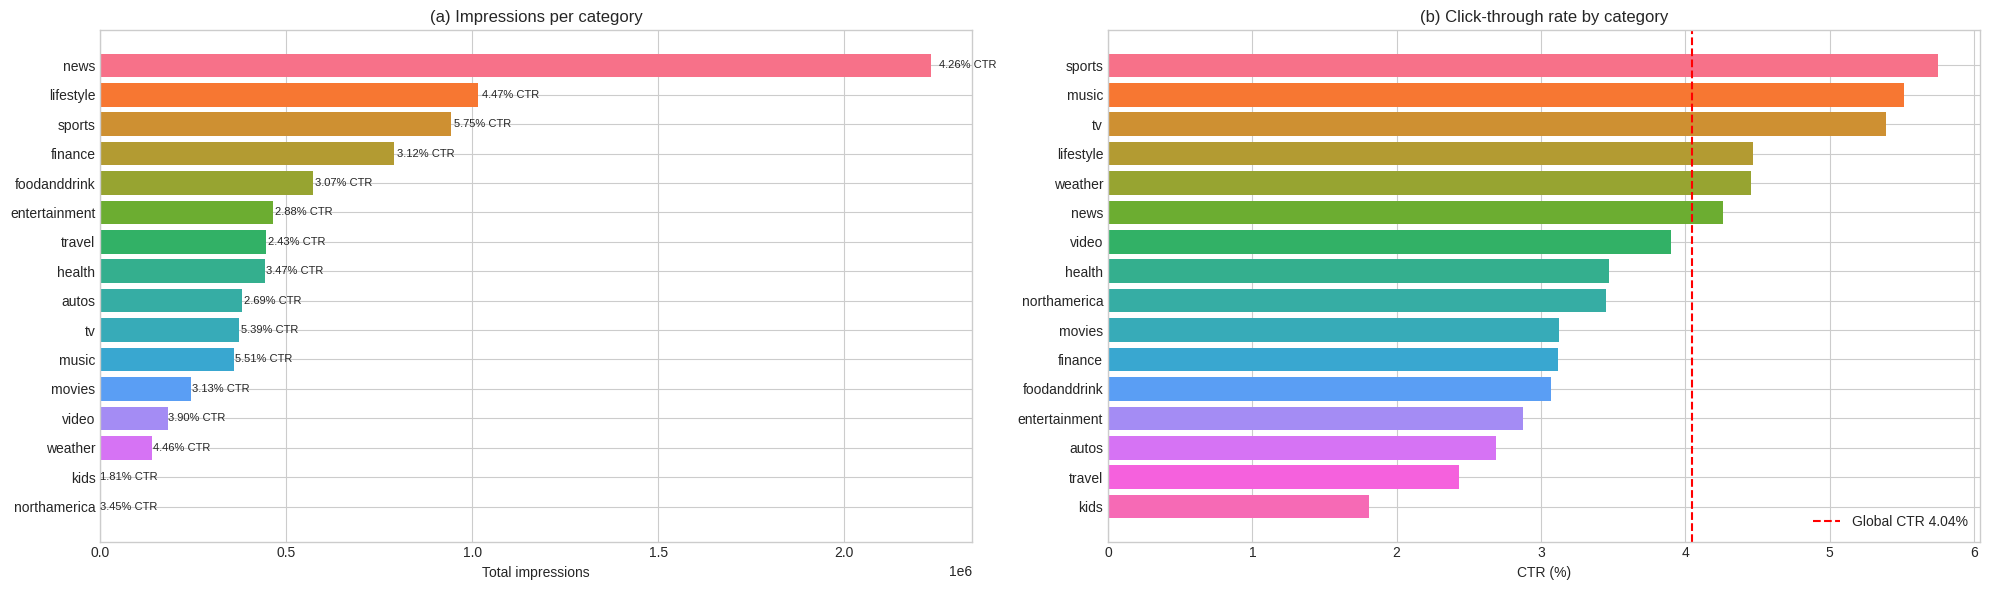

               impressions  clicks    ctr
category                                 
news               2232125   95172 0.0426
lifestyle          1016267   45431 0.0447
sports              942187   54220 0.0575
finance             789133   24610 0.0312
foodanddrink        572554   17579 0.0307
entertainment       464494   13362 0.0288
travel              446318   10858 0.0243
health              441673   15331 0.0347
autos               382055   10282 0.0269
tv                  374229   20176 0.0539
music               358613   19776 0.0551
movies              243102    7604 0.0313
video               181367    7076 0.0390
weather             140130    6246 0.0446
kids                   166       3 0.0181
northamerica            29       1 0.0345


In [19]:
# Analysis by category
news_lookup = news.set_index('newsId')[['category','subCategory','title']]
train_with_cat = train_clicks.join(news_lookup, on = 'newsId')
all_with_cat   = all_interactions.join(news_lookup, on = 'newsId')

# Compile the stats by cat
cat_stats = (all_with_cat.groupby('category').agg(impressions = ('clicked','count'), clicks = ('clicked','sum')).assign(ctr = lambda d: d['clicks']/d['impressions']).sort_values('impressions', ascending = False))

fig, axes = plt.subplots(1, 2, figsize = (20, 6))

# (a) Volume per category
ax = axes[0]
palette = sns.color_palette('husl', len(cat_stats))
bars = ax.barh(cat_stats.index, cat_stats['impressions'], color=palette)
ax.set_xlabel('Total impressions')
ax.set_title('(a) Impressions per category')
ax.invert_yaxis()
for bar, (_, row) in zip(bars, cat_stats.iterrows()):

    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
            f'{row["ctr"]:.2%} CTR', va='center', fontsize=8)

# (b) CTR per category (sorted)
ax = axes[1]
cat_ctr = cat_stats.sort_values('ctr', ascending=False)
bars2   = ax.barh(cat_ctr.index, cat_ctr['ctr']*100, color=palette)
ax.set_xlabel('CTR (%)')
ax.set_title('(b) Click-through rate by category')
ax.invert_yaxis()
ax.axvline(GLOBAL_CTR*100, color = 'red', ls = '--', lw = 1.5, label = f'Global CTR {GLOBAL_CTR:.2%}')
ax.legend()

plt.tight_layout()
plt.savefig('eda_categories.png', dpi=150, bbox_inches='tight')
plt.show()

print(cat_stats.to_string())

In [20]:
all_interactions.head()

,userId,newsId,clicked,timestamp,split
0,U13740,N55689,1,1573463158,train
1,U13740,N35729,0,1573463158,train
2,U91836,N20678,0,1573582290,train
3,U91836,N39317,0,1573582290,train
4,U91836,N58114,0,1573582290,train


In [21]:
all_interactions['split'].value_counts()

,count
split,
train,5843444
dev,2740998


In [22]:
# Analysis of cold start data
hist_train = parse_history_length(raw_train)
hist_dev   = parse_history_length(raw_dev)

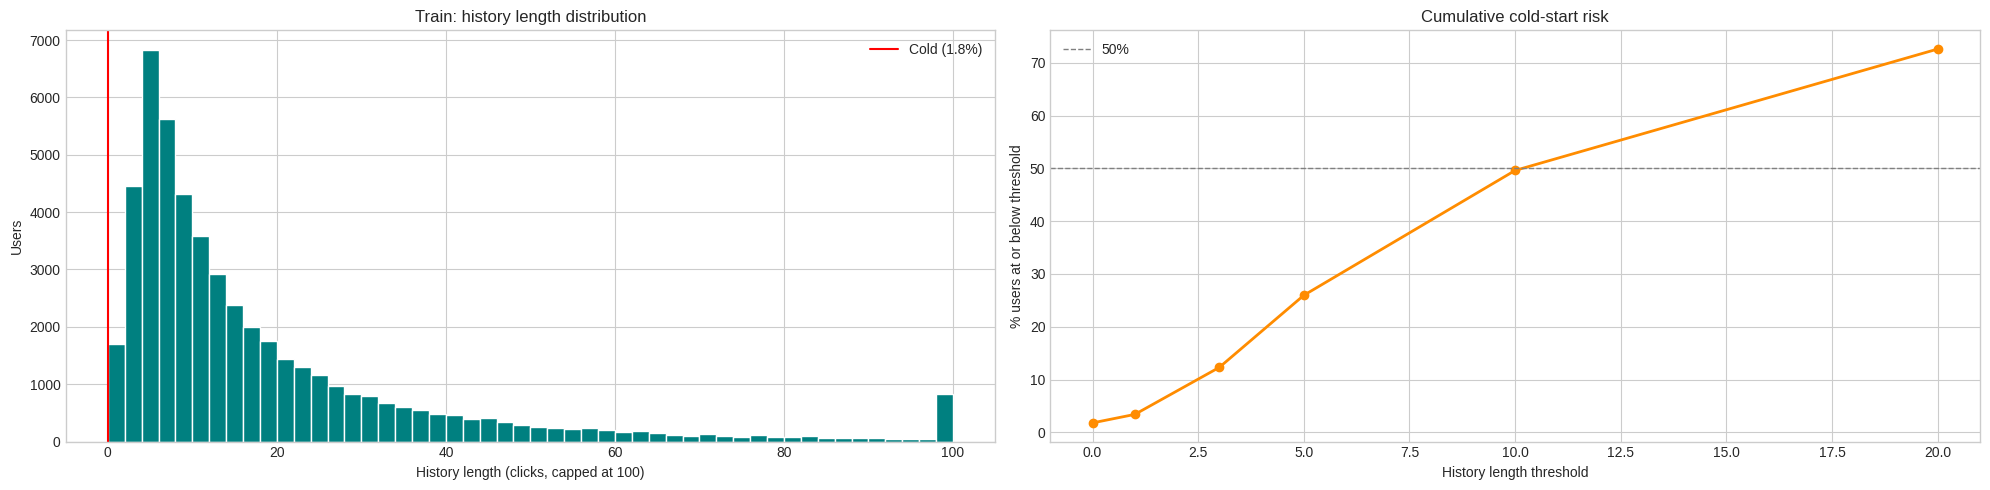

Train users with zero history : 892  (1.78%)
Train users with ≤5 history   : 12,979  (25.96%)


In [23]:
# Visualize the cold start ratios
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

ax = axes[0]
ax.hist(hist_train.clip(upper=100), bins=50, color='teal', edgecolor='white', lw=0.4)
ax.set_xlabel('History length (clicks, capped at 100)')
ax.set_ylabel('Users')
ax.set_title('Train: history length distribution')
cold_frac = (hist_train == 0).mean()
ax.axvline(0, color='red', lw=1.5, label=f'Cold ({cold_frac:.1%})')
ax.legend()

ax = axes[1]
thresholds = [0, 1, 3, 5, 10, 20]
fracs = [(hist_train <= t).mean() for t in thresholds]
ax.plot(thresholds, [f*100 for f in fracs], 'o-', color='darkorange', lw=2)
ax.set_xlabel('History length threshold')
ax.set_ylabel('% users at or below threshold')
ax.set_title('Cumulative cold-start risk')
ax.axhline(50, color='grey', ls='--', lw=1, label='50%')
ax.legend()

plt.tight_layout()
plt.savefig('eda_coldstart.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Train users with zero history : {(hist_train==0).sum():,}  ({cold_frac:.2%})')
print(f'Train users with ≤5 history   : {(hist_train<=5).sum():,}  ({(hist_train<=5).mean():.2%})')

[Back to top](#top)

---

## <a id="sec-3"></a>3. Feature engineering

We construct four reusable feature tables:

- **`user_stats`** — per-user: click count, active days, click frequency, favourite category
- **`article_feat`** — per-article: click count (log), Bayesian CTR, category one-hot, TF-IDF centroid
- **`user_cat_affinity`** — (user × category) matrix of normalised click preferences
- **`lgb_train_df`** — fully assembled (user, article, label) frame for the base LightGBM ranker

The TF-IDF vectoriser is fit on training article titles+abstracts only and transforms both train and dev articles, preventing feature leakage from future text.


In [24]:
# Compile user fts
user_stats = train_clicks.groupby('userId').agg(click_count  = ('newsId', 'count'), first_ts     = ('timestamp', 'min'), last_ts      = ('timestamp', 'max'),)
user_stats['active_days'] = ((user_stats['last_ts'] - user_stats['first_ts']) / 86_400).clip(lower = 1).astype('float32')
user_stats['click_freq'] = (user_stats['click_count'] / user_stats['active_days']).astype('float32')

fav_cat = (train_with_cat.groupby(['userId','category'])['clicked'].count().reset_index().sort_values('clicked', ascending = False).drop_duplicates('userId').set_index('userId')['category'])
user_stats['fav_category'] = fav_cat

user_stats = user_stats.fillna({'fav_category': 'unknown'})
print(f'user_stats: {user_stats.shape}')
#print(user_stats.head())

# Compile article fts
article_feat = (pop_stats[['click_count','impressions','bayesian_ctr']].rename(columns={'click_count':'global_clicks', 'impressions':'global_impressions'}))
article_feat['log_clicks']   = np.log1p(article_feat['global_clicks']).astype('float32')
article_feat['log_impr']     = np.log1p(article_feat['global_impressions']).astype('float32')
article_feat = article_feat.join(news.set_index('newsId')[['category','subCategory','text']], how = 'left')

# Title length as a signal (longer abstracts may have more information)
#article_feat['title_len']    = article_feat['title'].fillna('').apply(len).astype('float32')
#article_feat['abstract_len'] = article_feat['abstract'].fillna('').apply(len).astype('float32')
article_feat['article_len'] = article_feat['text'].fillna('').apply(len).astype('float32')
print(f'article_feat: {article_feat.shape}')
#print(article_feat.head())

user_stats: (50000, 6)
article_feat: (7713, 9)


In [25]:
train_cat_vocab = pd.get_dummies(article_feat['category'].dropna(), prefix = 'cat').columns

all_news_cat    = news.set_index('newsId')['category'].dropna()
article_cat     = (pd.get_dummies(all_news_cat, prefix='cat').astype('float32').reindex(columns = train_cat_vocab, fill_value = 0))

cat_cols = article_cat.columns.tolist()
print(f'Category columns ({len(cat_cols)}): {cat_cols}')
print(f'article_cat covers {len(article_cat):,} articles  '
      f'(train: {len(article_feat):,}  dev-only: {len(article_cat)-len(article_feat):,})')

Category columns (16): ['cat_autos', 'cat_entertainment', 'cat_finance', 'cat_foodanddrink', 'cat_health', 'cat_kids', 'cat_lifestyle', 'cat_movies', 'cat_music', 'cat_news', 'cat_northamerica', 'cat_sports', 'cat_travel', 'cat_tv', 'cat_video', 'cat_weather']
article_cat covers 65,238 articles  (train: 7,713  dev-only: 57,525)


In [26]:
user_stats.head()

,click_count,first_ts,last_ts,active_days,click_freq,fav_category
userId,,,,,,
U100,1,1573544052,1573544052,1.0000,1.0000,news
U1000,4,1573686978,1573771041,1.0000,4.0000,news
U10001,3,1573450221,1573710414,3.0115,0.9962,autos
U10003,3,1573455962,1573481638,1.0000,3.0000,sports
U10008,1,1573308813,1573308813,1.0000,1.0000,weather


In [27]:
article_feat.head()

,global_clicks,global_impressions,bayesian_ctr,log_clicks,log_impr,category,subCategory,text,article_len
newsId,,,,,,,,,
N10032,1,190,0.0126,0.6931,5.2523,foodanddrink,recipes,14 butternut squash recipes for delightfully c...,172.0000
N10051,1,370,0.0072,0.6931,5.9162,autos,autosenthusiasts,VW ID.3 Electric Motor Is So Compact That Fits...,160.0000
N10056,6,38,0.0912,1.9459,3.6636,sports,football_nfl,"Russell Wilson, Richard Sherman swap jerseys d...",176.0000
N10057,2,41,0.0442,1.0986,3.7377,weather,weathertopstories,Venice swamped by highest tide in more than 50...,243.0000
N1006,1,2,0.0581,0.6931,1.0986,sports,football_nfl,"Jaguars vs. Colts: A.J. Cann, Will Richardson ...",487.0000


In [28]:
article_cat.head()

,cat_autos,cat_entertainment,cat_finance,cat_foodanddrink,cat_health,cat_kids,cat_lifestyle,cat_movies,cat_music,cat_news,cat_northamerica,cat_sports,cat_travel,cat_tv,cat_video,cat_weather
newsId,,,,,,,,,,,,,,,,
N55528,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
N19639,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
N61837,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
N53526,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
N38324,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [29]:
article_feat.head()

,global_clicks,global_impressions,bayesian_ctr,log_clicks,log_impr,category,subCategory,text,article_len
newsId,,,,,,,,,
N10032,1,190,0.0126,0.6931,5.2523,foodanddrink,recipes,14 butternut squash recipes for delightfully c...,172.0000
N10051,1,370,0.0072,0.6931,5.9162,autos,autosenthusiasts,VW ID.3 Electric Motor Is So Compact That Fits...,160.0000
N10056,6,38,0.0912,1.9459,3.6636,sports,football_nfl,"Russell Wilson, Richard Sherman swap jerseys d...",176.0000
N10057,2,41,0.0442,1.0986,3.7377,weather,weathertopstories,Venice swamped by highest tide in more than 50...,243.0000
N1006,1,2,0.0581,0.6931,1.0986,sports,football_nfl,"Jaguars vs. Colts: A.J. Cann, Will Richardson ...",487.0000


In [30]:
# Perform TF-IDF
train_news_ids = set(train_clicks['newsId'].unique())

news_indexed  = news.set_index('newsId')
train_texts   = news_indexed.loc[news_indexed.index.isin(train_news_ids), 'text'].fillna('')

print('Fitting TF-IDF on train articles...', end = ' ', flush = True)
tfidf = TfidfVectorizer(max_features = 10000, sublinear_tf = True, min_df = 2, ngram_range = (1,2))
tfidf.fit(train_texts)
print('done.')

# Transform all articles (train + dev)
all_texts  = news_indexed['text'].fillna('')
tfidf_mat  = tfidf.transform(all_texts)    # sparse (n_articles, 5000)
tfidf_idx  = {nid: i for i, nid in enumerate(news_indexed.index)}
print(f'TF-IDF matrix: {tfidf_mat.shape}  nnz={tfidf_mat.nnz:,}')

Fitting TF-IDF on train articles... done.
TF-IDF matrix: (65238, 10000)  nnz=2,566,812


In [31]:
# Create an affinity matrix for user-category: compute normalised click counts per category
user_cat = (train_with_cat.groupby(['userId','category'])['clicked'].count().unstack(fill_value=0).astype('float32'))

# Normalise rows to unit L2 norm
norms = np.linalg.norm(user_cat.values, axis = 1, keepdims = True).clip(min = 1e-9)
user_cat_affinity = pd.DataFrame(user_cat.values / norms, index   = user_cat.index, columns = user_cat.columns)

# Align article-category matrix columns with user-category matrix
article_cat_aligned = article_cat.reindex(columns=user_cat.columns, fill_value=0)
article_cat_norm    = normalize(article_cat_aligned.values.astype('float32'), norm='l2', axis=1)
article_cat_idx     = article_cat_aligned.index.tolist()  # ordered article IDs

print(f'user_cat_affinity : {user_cat_affinity.shape}')
print(f'article_cat_norm  : {article_cat_norm.shape}')
user_cat_affinity.head(3)

user_cat_affinity : (50000, 16)
article_cat_norm  : (65238, 16)


category,autos,entertainment,finance,foodanddrink,health,kids,lifestyle,movies,music,news,northamerica,sports,travel,tv,video,weather
userId,,,,,,,,,,,,,,,,
U100,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
U1000,0.0000,0.0000,0.0000,0.4082,0.0000,0.0000,0.0000,0.4082,0.0000,0.8165,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
U10001,0.5774,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5774,0.5774,0.0000,0.0000,0.0000


[Back to top](#top)

---

## <a id="sec-4"></a>4. Article-based collaborative filtering

### 📖 Batched sparse co-click similarity

We build a **article × user click matrix** from positive training interactions, normalise rows (articles) to unit L2 norm, and compute cosine similarities between articles in batches to avoid OOM. The result is an `item_sim_lookup` dict mapping `newsId → [(newsId, similarity), …]` for the top-50 nearest neighbours.

This creates the **S3 retriever**: for a given user, find all articles they clicked, look up each article's nearest neighbours, aggregate scores (weighted by similarity × recency), and surface the top-N unseen articles.


In [32]:
%%time

# Build article x user_click matrices
article_ids_cf = train_clicks['newsId'].unique()
user_ids_cf    = train_clicks['userId'].unique()

a_idx = {a: i for i, a in enumerate(article_ids_cf)}
u_idx = {u: i for i, u in enumerate(user_ids_cf)}
idx_a = {i: a for a, i in a_idx.items()}

R_cf = csr_matrix((np.ones(len(train_clicks), dtype='float32'), (train_clicks['newsId'].map(a_idx).values, train_clicks['userId'].map(u_idx).values)), shape = (len(article_ids_cf), len(user_ids_cf)))

R_norm_cf = normalize(R_cf, norm = 'l2', axis = 1)
print(f'Click matrix: {R_cf.shape}  nnz={R_cf.nnz:,}')
print(f'Memory: R={R_cf.data.nbytes/1e6:.0f} MB  R_norm={R_norm_cf.data.nbytes/1e6:.0f} MB')

Click matrix: (7713, 50000)  nnz=234,468
Memory: R=1 MB  R_norm=1 MB
CPU times: user 221 ms, sys: 1.02 ms, total: 222 ms
Wall time: 221 ms


In [33]:
# Perform a batched knn to get similar articles
item_sim_lookup = {}
n_articles_cf   = R_norm_cf.shape[0]
t0              = time.time()

for start in range(0, n_articles_cf, 1000):

    batch = R_norm_cf[start : start + 1000]
    sims  = (batch @ R_norm_cf.T).toarray()

    for local_i, sim_row in enumerate(sims):

        global_i          = start + local_i
        sim_row[global_i] = 0.0
        top_k = np.argpartition(sim_row, -50)[-50:]
        top_k = top_k[np.argsort(sim_row[top_k])[::-1]]
        aid   = idx_a[global_i]
        item_sim_lookup[aid] = [(idx_a[j], float(sim_row[j])) for j in top_k]

    if start % 1000 == 0:
        print(f'  {start:>6}/{n_articles_cf}  {time.time()-t0:.0f}s')

del R_cf, R_norm_cf; gc.collect()
print(f'\nItem-sim lookup: {len(item_sim_lookup):,} articles in {time.time()-t0:.0f}s')

       0/7713  1s
    1000/7713  1s
    2000/7713  2s
    3000/7713  2s
    4000/7713  2s
    5000/7713  3s
    6000/7713  3s
    7000/7713  4s

Item-sim lookup: 7,713 articles in 4s


[Back to top](#top)

---

## <a id="sec-5"></a>5. Temporal sequence modelling

### 📖 Recency-weighted taste vectors

Recent clicks should dominate a user's preference profile — an article clicked yesterday matters more than one from three weeks ago. We compute per-user **category taste vectors** using exponential decay (half-life = 7 days, matching news freshness intuition). The resulting matrix enables fast batch dot-products at inference time.


In [34]:
# Compute recency weighted taste vectors -  one week
DECAY_HALF_LIFE = 7
DECAY_K         = np.log(2) / DECAY_HALF_LIFE
now_ts          = int(train_clicks['timestamp'].max())

clicks_ts = train_clicks[['userId','newsId','timestamp']].copy()
clicks_ts['weight'] = np.exp(-DECAY_K * (now_ts - clicks_ts['timestamp'].values.astype('float64')) / 86_400).astype('float32')

# Join category info for each click
clicks_ts = clicks_ts.join(news.set_index('newsId')[['category']], on='newsId')
clicks_ts = clicks_ts.dropna(subset=['category'])

# Aggregate: user × category, weighted by recency
user_taste = (clicks_ts.groupby(['userId','category'])['weight'].sum().unstack(fill_value=0).astype('float32'))

# Normalise to unit L2 so dot-products equal cosine similarity
taste_norms  = np.linalg.norm(user_taste.values, axis=1, keepdims=True).clip(min=1e-9)
user_taste_norm = pd.DataFrame(user_taste.values / taste_norms, index   = user_taste.index, columns = user_taste.columns)

# Align with article-category matrix
article_cat_taste = article_cat.reindex(columns=user_taste.columns, fill_value=0)
article_cat_taste_norm = normalize(article_cat_taste.values.astype('float32'), norm='l2', axis=1)
taste_article_idx = article_cat_taste.index.tolist()

print(f'user_taste_norm   : {user_taste_norm.shape}')
print(f'article_cat_taste : {article_cat_taste_norm.shape}')
user_taste_norm.head(3)

user_taste_norm   : (50000, 16)
article_cat_taste : (65238, 16)


category,autos,entertainment,finance,foodanddrink,health,kids,lifestyle,movies,music,news,northamerica,sports,travel,tv,video,weather
userId,,,,,,,,,,,,,,,,
U100,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
U1000,0.0000,0.0000,0.0000,0.4027,0.0000,0.0000,0.0000,0.4402,0.0000,0.8025,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
U10001,0.6261,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4647,0.6261,0.0000,0.0000,0.0000


In [35]:
# Compile the lgb ft matrix
FEATURE_COLS = ['u_click_count', 'u_click_freq', 'm_log_clicks',  'm_log_impr', 'm_bayesian_ctr', 'm_article_len', 'cat_affinity',  'taste_affinity',]
TRAIN_USERS_SAMPLE = 5000
NEGATIVES_PER_POS  = 4
K_CAND             = 200
rng_feat           = np.random.default_rng(100)

In [36]:
# Assemble user, article, label sets
sample_users   = np.array(list(train_users & set(user_stats.index)))

print('Computing user affinity matrix..')

_uca           = user_cat_affinity.reindex(sample_users).fillna(0).values.astype('float32')
_uca_norms     = np.linalg.norm(_uca, axis=1, keepdims=True).clip(min=1e-9)
s2_scores_base = article_cat_norm @ (_uca / _uca_norms).T

# Clear the data
del _uca, _uca_norms

print('Computing user tastes matrix..')
_taste         = user_taste_norm.reindex(sample_users).fillna(0).values.astype('float32')
s4_scores_base = article_cat_taste_norm @ _taste.T

# Clear the data
del _taste

pair_rows = []
user_click_sets = train_clicks.groupby('userId')['newsId'].apply(set).to_dict()
print('Complete.')

Computing user affinity matrix..
Computing user tastes matrix..
Complete.


In [37]:
# Precompile added fts
# article_cat_idx.index(aid) is O(n) per call — replace with a dict
art_pos = {a: i for i, a in enumerate(article_cat_idx)}
taste_pos = {a: i for i, a in enumerate(taste_article_idx)}

# Pull article features into plain dicts once — avoids repeated .loc overhead
af_log_clicks   = article_feat['log_clicks'].to_dict()
af_log_impr     = article_feat['log_impr'].to_dict()
af_bayesian_ctr = article_feat['bayesian_ctr'].to_dict()
af_article_len  = article_feat['article_len'].to_dict()

# Pull user features into plain dicts once
us_click_count = user_stats['click_count'].to_dict()
us_click_freq  = user_stats['click_freq'].to_dict()

user_click_sets = train_clicks.groupby('userId')['newsId'].apply(set).to_dict()

In [38]:
%%time

# Iterate
pair_rows = []

for uid_i, uid in enumerate(sample_users):

    clicked_set = user_click_sets.get(uid, set())

    if not clicked_set:

        continue

    # Candidate pool — no seen filter during training (positives must be present)
    cand_pop = POPULARITY_POOL[:K_CAND * 2]
    cand_cf  = []

    for aid in list(clicked_set)[:10]:

        for n_aid, _ in item_sim_lookup.get(aid, [])[:20]:

            cand_cf.append(n_aid)

    candidates = list(dict.fromkeys(cand_pop + cand_cf))[:K_CAND]
    positives  = [a for a in candidates if a in clicked_set]
    negatives  = [a for a in candidates if a not in clicked_set]

    if not positives:

        continue

    neg_sample = negatives[:len(positives) * NEGATIVES_PER_POS]

    s2_col = s2_scores_base[:, uid_i]
    s4_col = s4_scores_base[:, uid_i]

    # User features fetched once per user, not once per (user, article) pair
    u_click_count = float(us_click_count.get(uid, 0))
    u_click_freq  = float(us_click_freq.get(uid, 0))

    for aid, lbl in [(a, 1) for a in positives] + [(a, 0) for a in neg_sample]:

        art_i   = art_pos.get(aid, -1)
        cat_aff = float(s2_col[art_i]) if art_i >= 0 else 0.0
        tst_aff = float(s4_col[art_i]) if art_i >= 0 else 0.0

        pair_rows.append((
            uid, aid, lbl,
            u_click_count,
            u_click_freq,
            float(af_log_clicks.get(aid,   0)),
            float(af_log_impr.get(aid,     0)),
            float(af_bayesian_ctr.get(aid, 0)),
            float(af_article_len.get(aid,  0)),
            cat_aff,
            tst_aff,
        ))

lgb_train_df = pd.DataFrame(pair_rows, columns=['userId', 'newsId', 'label'] + FEATURE_COLS)

print(f'Training pairs: {len(lgb_train_df):,}  '
      f'(pos={lgb_train_df["label"].sum():.0f}  '
      f'neg={(lgb_train_df["label"]==0).sum():.0f})')

Training pairs: 281,900  (pos=56380  neg=225520)
CPU times: user 5.15 s, sys: 48.5 ms, total: 5.2 s
Wall time: 5.2 s


In [29]:
lgb_train_df.head()

,userId,newsId,label,u_click_count,u_click_freq,m_log_clicks,m_log_impr,m_bayesian_ctr,m_article_len,cat_affinity,taste_affinity
0,U87449,N49279,1,21.0000,4.2555,7.7280,8.7371,0.3618,126.0000,0.0000,0.0000
1,U87449,N287,1,21.0000,4.2555,7.6634,9.2123,0.2115,158.0000,0.0000,0.0000
2,U87449,N63970,1,21.0000,4.2555,7.8552,9.5664,0.1801,102.0000,0.0000,0.0000
3,U87449,N23446,1,21.0000,4.2555,7.5658,9.6487,0.1242,279.0000,0.0000,0.0000
4,U87449,N51048,1,21.0000,4.2555,7.5369,9.8649,0.0973,51.0000,0.0000,0.0000


[Back to top](#top)

---

## <a id="sec-6"></a>6. Evaluation harness & S1–S5 strategies

Five metrics evaluated at K = 5 and K = 10. The composite score is their unweighted average.

| Strategy | Description |
|----------|-------------|
| **S1** | Global popularity — Bayesian CTR ranking |
| **S2** | Category affinity — dot product of user preferences with article categories |
| **S3** | Item-based CF — aggregate neighbour scores from clicked articles |
| **S4** | Temporal taste — recency-weighted category preference |
| **S5** | LightGBM pointwise ranker (base model) |


In [39]:
%%time

# Train light GBM model
xtrain = lgb_train_df[FEATURE_COLS].values
ytrain = lgb_train_df['label'].values

del lgb_train_df; gc.collect()

x_tr, x_val, y_tr, y_val = train_test_split(xtrain, ytrain, test_size = 0.15, random_state = 100, stratify = ytrain)

lgb_params = {'objective'       : 'binary',
              'metric'          : 'auc',
              'learning_rate'   : 0.05,
              'feature_fraction': 0.8,
              'bagging_fraction': 0.8,
              'bagging_freq'    : 5,
              'verbose'         : -1,
              'n_jobs'          : -1,}

lgb_model = lgb.train(lgb_params, lgb.Dataset(x_tr, label=y_tr), num_boost_round = 500, valid_sets      = [lgb.Dataset(x_val, label=y_val)], callbacks       = [lgb.early_stopping(30, verbose=False), lgb.log_evaluation(100)],)
del xtrain, x_tr, x_val, y_tr, y_val; gc.collect()
print(f'\nBase LGB trees: {lgb_model.num_trees()}')

[100]	valid_0's auc: 0.91277
[200]	valid_0's auc: 0.914439
[300]	valid_0's auc: 0.9151
[400]	valid_0's auc: 0.915391

Base LGB trees: 450
CPU times: user 36.4 s, sys: 65.8 ms, total: 36.5 s
Wall time: 5.57 s


[Back to top](#top)

---

## <a id="sec-7"></a>7. S6 architecture & cold-start gate

### Architecture

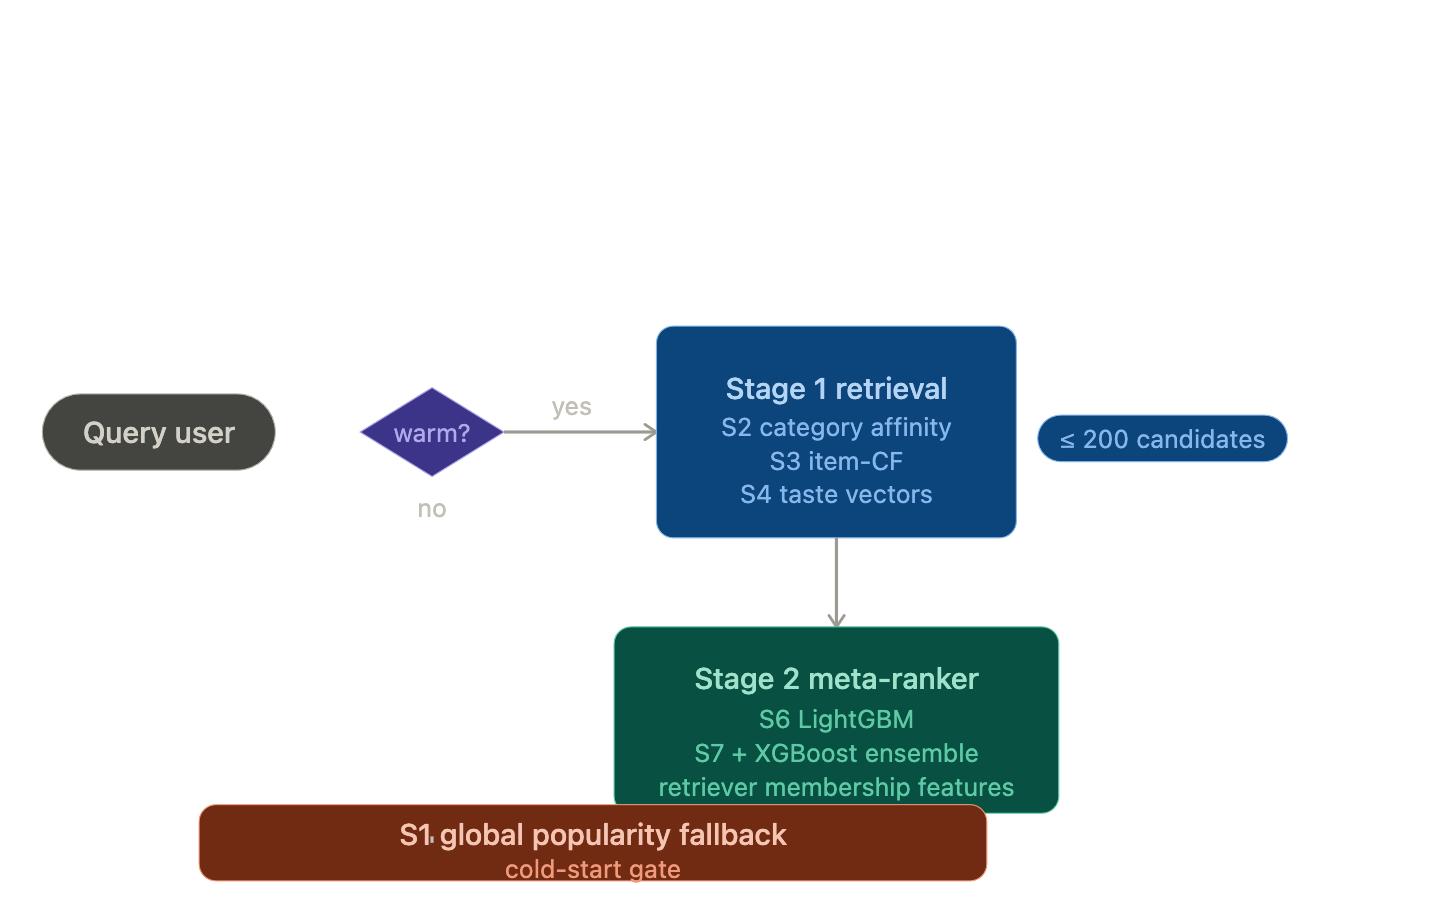

### Cold-start gate
A user is **cold** if they have fewer than 2 training clicks. Cold users skip the two-stage pipeline entirely and fall back to global popularity ranking.


In [40]:
# Cold start gate
eval_warm = eval_df
cold_in_eval = sum(is_cold(uid) for uid in eval_warm['userId'])
print(f'Cold users in eval fold: {cold_in_eval:,}  '
      f'({100*cold_in_eval/len(eval_warm):.1f}%)')

Cold users in eval fold: 974  (16.4%)


[Back to top..](#top)

---

## <a id="sec-8"></a>8. Stage 1 — Expanded candidate pool

Stage 1 merges four retrievers to maximise recall before the expensive re-ranking step. We measure **Stage-1 Recall@200** on a diagnostic sample: what fraction of the user's ground-truth articles appear anywhere in the 200-candidate pool?


In [41]:
# Generate candidates in stage 1
N_STAGE1 = 200

def stage1_candidates(uid):

    if is_cold(uid):

        return _filter_seen(POPULARITY_POOL, uid)[:N_STAGE1]

    pool = list(dict.fromkeys(
        s1_popularity(uid, N_STAGE1//4) +
        s2_category(uid,   N_STAGE1//4) +
        s3_itemcf(uid,     N_STAGE1//2) +
        s4_temporal(uid,   N_STAGE1//4)
    ))
    return pool[:N_STAGE1]

# Recall diagnostic
DIAG_N = 500
diag_users = eval_warm.sample(n=min(DIAG_N, len(eval_warm)), random_state=100)
recalls = []

for _, row in diag_users.iterrows():

    pool = set(stage1_candidates(row['userId']))
    true = row['true_items']
    recalls.append(len(pool & true) / len(true) if true else 0.0)

print(f'Stage-1 Recall@{N_STAGE1} (n={DIAG_N}): {np.mean(recalls):.4f}')
print(f'  Min: {np.min(recalls):.4f}  Max: {np.max(recalls):.4f}  Std: {np.std(recalls):.4f}')

Stage-1 Recall@200 (n=500): 0.0532
  Min: 0.0000  Max: 1.0000  Std: 0.1817


---

## <a id="sec-9"></a>9. Stage 2 — Meta-ranker training

The meta-ranker sees **enriched features** beyond what the base LightGBM sees:

| Feature group | Features |
|---------------|----------|
| Base ranker features | All 9 features from Section 5 |
| Retriever membership | `in_s2`, `in_s3`, `in_s4` (binary flags) |
| Retriever ranks | `rank_s2`, `rank_s3`, `rank_s4` (position in each retriever's list) |
| Ensemble depth | `n_retrievers` (how many retrievers surfaced this candidate) |
| Base LGB score | `s5_score` (predicted probability from the base model) |

This lets the meta-ranker learn which retrievers are reliable for which users and articles.


In [42]:
STAGE2_FEATURE_COLS = FEATURE_COLS + ['in_s2','in_s3','in_s4','rank_s2','rank_s3','rank_s4','n_retrievers','s5_score']
print(f'Stage-2 features: {len(STAGE2_FEATURE_COLS)}')

Stage-2 features: 16


In [67]:
%%time
META_SESSION_FRAC = 0.3
CHUNK_SIZE = 500

# Build the base df
meta_df = interactions_train[['userId', 'newsId', 'clicked', 'timestamp']].copy()
meta_df['newsId'] = meta_df['newsId'].astype(str)

session_has_click = (meta_df.groupby(['userId', 'timestamp'])['clicked'].transform('sum') > 0)
meta_df = meta_df[session_has_click].reset_index(drop = True)

all_sessions = meta_df[['userId', 'timestamp']].drop_duplicates()
sampled      = all_sessions.sample(frac=META_SESSION_FRAC, random_state=100)
meta_df      = meta_df.merge(sampled, on=['userId', 'timestamp'])
del all_sessions, sampled; gc.collect()

# Join the fts
meta_df = meta_df.join(user_stats[['click_count', 'click_freq']].rename(columns={'click_count': 'u_click_count', 'click_freq': 'u_click_freq'}), on='userId')
meta_df = meta_df.join(article_feat[['log_clicks', 'log_impr', 'bayesian_ctr', 'article_len']].rename(columns={'log_clicks': 'm_log_clicks', 'log_impr': 'm_log_impr', 'bayesian_ctr': 'm_bayesian_ctr', 'article_len': 'm_article_len'}), on = 'newsId')

newsid_to_cat = news.set_index('newsId')['category'].to_dict()
meta_df['category'] = meta_df['newsId'].map(newsid_to_cat)

# ── Category affinities ────────────────────────────────────────────────────────
# Restrict rows to users present in meta_df to avoid building a huge long frame,
# but keep ALL columns for each matrix independently — never cross-filter by the
# other matrix's columns, which was what corrupted taste_affinity previously.
relevant_users = meta_df['userId'].unique()

uca_sub  = user_cat_affinity.reindex(index=relevant_users)
uca_long = (uca_sub.stack().reset_index().rename(columns={'level_0': 'userId', 'level_1': 'category', 0: 'cat_affinity'}))

del uca_sub

meta_df = meta_df.merge(uca_long, on=['userId', 'category'], how='left')

del uca_long; gc.collect()

uta_sub  = user_taste_norm.reindex(index=relevant_users)     # all columns kept
uta_long = (uta_sub.stack().reset_index().rename(columns = {'level_0': 'userId', 'level_1': 'category', 0: 'taste_affinity'}))

del uta_sub, relevant_users

meta_df = meta_df.merge(uta_long, on=['userId', 'category'], how='left')

del uta_long; gc.collect()

meta_df[FEATURE_COLS] = meta_df[FEATURE_COLS].fillna(0)

# Find retriever membership
unique_users = np.array(meta_df['userId'].unique())
n_users      = len(unique_users)
print(f"Building retriever membership for {n_users:,} users...", flush=True)

article_cat_idx_arr   = np.array(article_cat_idx)
taste_article_idx_arr = np.array(taste_article_idx)

# S2: category-affinity retriever
uca_mat   = user_cat_affinity.reindex(unique_users).fillna(0).values.astype('float32')
uca_norms = np.linalg.norm(uca_mat, axis = 1, keepdims = True).clip(min = 1e-9)
uca_mat  /= uca_norms

del uca_norms

s2_df = chunked_topn(article_cat_norm, uca_mat, article_cat_idx_arr, N_STAGE1, 'rank_s2')

del uca_mat

meta_df = meta_df.merge(s2_df, on=['userId', 'newsId'], how='left')

del s2_df; gc.collect()

# S3: item-CF
s3_rows = []

for uid in unique_users:

    for rank, aid in enumerate(s3_itemcf(uid, N_STAGE1)):

        s3_rows.append((uid, aid, rank))

s3_df = pd.DataFrame(s3_rows, columns=['userId', 'newsId', 'rank_s3'])
del s3_rows
meta_df = meta_df.merge(s3_df, on=['userId', 'newsId'], how='left')
del s3_df; gc.collect()

# S4: taste-vector retriever
tvec_mat = user_taste_norm.reindex(unique_users).fillna(0).values.astype('float32')
s4_df    = chunked_topn(article_cat_taste_norm, tvec_mat, taste_article_idx_arr, N_STAGE1, 'rank_s4')
del tvec_mat
meta_df = meta_df.merge(s4_df, on=['userId', 'newsId'], how='left')
del s4_df; gc.collect()

# Derive feature flags
meta_df['in_s2']        = meta_df['rank_s2'].notna().astype('int8')
meta_df['in_s3']        = meta_df['rank_s3'].notna().astype('int8')
meta_df['in_s4']        = meta_df['rank_s4'].notna().astype('int8')
meta_df['rank_s2']      = meta_df['rank_s2'].fillna(N_STAGE1).astype('int16')
meta_df['rank_s3']      = meta_df['rank_s3'].fillna(N_STAGE1).astype('int16')
meta_df['rank_s4']      = meta_df['rank_s4'].fillna(N_STAGE1).astype('int16')
meta_df['n_retrievers'] = (meta_df['in_s2'] + meta_df['in_s3'] + meta_df['in_s4']).astype('int8')
meta_df['s5_score']     = 0.0

meta_train_df = (meta_df[['userId', 'newsId'] + STAGE2_FEATURE_COLS + ['clicked']].rename(columns={'clicked': 'label'}).reset_index(drop=True))

n_pos = int(meta_train_df['label'].sum())
print(f'Meta-training pairs: {len(meta_train_df):,}  '
      f'(pos={n_pos:,}  neg={len(meta_train_df)-n_pos:,})')

Building retriever membership for 28,052 users...
Meta-training pairs: 1,782,581  (pos=71,206  neg=1,711,375)
CPU times: user 4min 25s, sys: 30.1 s, total: 4min 55s
Wall time: 2min 49s


In [69]:
meta_train_df.head()

,userId,newsId,u_click_count,u_click_freq,m_log_clicks,m_log_impr,m_bayesian_ctr,m_article_len,cat_affinity,taste_affinity,in_s2,in_s3,in_s4,rank_s2,rank_s3,rank_s4,n_retrievers,s5_score,label
0,U19739,N21119,18,3.4613,2.9957,7.4849,0.0115,318.0000,0.9608,0.9591,0,0,0,200,200,200,0,0.0000,1
1,U19739,N53696,18,3.4613,3.9890,7.5522,0.0282,509.0000,0.9608,0.9591,0,0,0,200,200,200,0,0.0000,0
2,U19739,N33619,18,3.4613,8.0855,9.6200,0.2149,163.0000,0.9608,0.9591,0,0,0,200,200,200,0,0.0000,1
3,U19739,N25722,18,3.4613,4.4886,8.1336,0.0260,254.0000,0.9608,0.9591,0,0,0,200,200,200,0,0.0000,0
4,U19739,N2869,18,3.4613,3.8067,8.4260,0.0100,87.0000,0.9608,0.9591,0,0,0,200,200,200,0,0.0000,0


In [70]:
%%time

# Fill in the s5 scores
xmeta_base = meta_train_df[FEATURE_COLS].values.astype('float32')
meta_train_df['s5_score'] = lgb_model.predict(xmeta_base)
del xmeta_base; gc.collect()

# Train the meta-ranker lgb model
xmeta = meta_train_df[STAGE2_FEATURE_COLS].values
ymeta = meta_train_df['label'].values

xm_tr, xm_val, ym_tr, ym_val = train_test_split(
    xmeta, ymeta, test_size=0.15, random_state=42, stratify=ymeta)

meta_lgb_params = {'objective'       : 'binary',
                    'metric'          : 'auc',
                    'learning_rate'   : 0.03,
                    'feature_fraction': 0.8,
                    'bagging_fraction': 0.8,
                    'bagging_freq'    : 5,
                    'verbose'         : -1,
                    'n_jobs'          : -1,}

meta_lgb = lgb.train(meta_lgb_params, lgb.Dataset(xm_tr, label=ym_tr), num_boost_round = 800, valid_sets = [lgb.Dataset(xm_val, label=ym_val)], callbacks = [lgb.early_stopping(40, verbose=False), lgb.log_evaluation(100)],)

# Train the meta-ranker xgboost model
xgb_meta = XGBClassifier(n_estimators  = 1000,
                         learning_rate = 0.05,
                         max_depth     = 6,
                         subsample     = 0.8,
                         colsample_bytree = 0.8,
                         eval_metric   = 'auc',
                         early_stopping_rounds = 30,
                         verbosity     = 0)

xgb_meta.fit(xm_tr, ym_tr, eval_set=[(xm_val, ym_val)], verbose=False)

print(f'Meta-LGB trees: {meta_lgb.num_trees()}')
print(f'Meta-XGB trees: {xgb_meta.best_iteration}')

[100]	valid_0's auc: 0.913629
[200]	valid_0's auc: 0.914943
[300]	valid_0's auc: 0.915528
[400]	valid_0's auc: 0.915832
[500]	valid_0's auc: 0.916133
[600]	valid_0's auc: 0.916388
[700]	valid_0's auc: 0.916634
[800]	valid_0's auc: 0.916711
Meta-LGB trees: 786
Meta-XGB trees: 999
CPU times: user 16min 20s, sys: 1.02 s, total: 16min 21s
Wall time: 2min 9s


In [71]:
del xmeta, xm_tr, xm_val, ym_tr, ym_val, meta_train_df; gc.collect()

321

[Back to top](#top)

---

## <a id="sec-10"></a>10. Full benchmark: S1 → S7

We evaluate all seven strategies on the held-out eval fold. Each strategy is given the same `eval_warm` users and the same ground-truth sets.


In [72]:
# Run the benchmark to compare all strategies
%%time

strategies = [('S1: Popularity',         s1_score),
              ('S2: Category Affinity',  s2_score),
              ('S3: Item-CF',            s3_score),
              ('S4: Temporal Taste',     s4_score),
              ('S5: LightGBM Base',      s5_score),
              ('S6: Meta-LGB (2-Stage)', s6_score),
              ('S7: Ensemble (LGB+XGB)', s7_score),]

all_results = {}
EVAL_N = min(1000, len(eval_warm))

for name, fn in strategies:

    for K in [5, 10]:

        print(f'  {name}  @K={K}...', end = ' ', flush = True)
        t0 = time.time()
        res = evaluate_strategy(fn, eval_warm, K=K, n=EVAL_N)
        print(f'{time.time()-t0:.0f}s  composite={res["composite"]:.4f}')
        all_results[(name, K)] = res

  S1: Popularity  @K=5... 0s  composite=0.2944
  S1: Popularity  @K=10... 0s  composite=0.3554
  S2: Category Affinity  @K=5... 75s  composite=0.2206
  S2: Category Affinity  @K=10... 75s  composite=0.2932
  S3: Item-CF  @K=5... 0s  composite=0.2192
  S3: Item-CF  @K=10... 0s  composite=0.2945
  S4: Temporal Taste  @K=5... 75s  composite=0.2206
  S4: Temporal Taste  @K=10... 75s  composite=0.2932
  S5: LightGBM Base  @K=5... 97s  composite=0.1828
  S5: LightGBM Base  @K=10... 95s  composite=0.2559
  S6: Meta-LGB (2-Stage)  @K=5... 328s  composite=0.2773
  S6: Meta-LGB (2-Stage)  @K=10... 330s  composite=0.3308
  S7: Ensemble (LGB+XGB)  @K=5... 366s  composite=0.2912
  S7: Ensemble (LGB+XGB)  @K=10... 366s  composite=0.3368
CPU times: user 2h 29min 20s, sys: 5.79 s, total: 2h 29min 26s
Wall time: 31min 23s


In [73]:
# Compile the leaderboard
records = []

for (name, K), res in all_results.items():

    records.append({'strategy': name, 'K': K, **res})

leaderboard = (pd.DataFrame(records).sort_values(['K','composite'], ascending = [True, False]).reset_index(drop=True))

for k_val in [5, 10]:

    print(f'\n{"="*65}')
    print(f'  LEADERBOARD  @  K = {k_val}')
    print('='*65)
    lb = leaderboard[leaderboard['K'] == k_val][['strategy'] + metric_keys + ['composite']]
    print(lb.to_string(index=False))


  LEADERBOARD  @  K = 5
              strategy  precision  recall     f1   ndcg  hit_rate  composite
        S1: Popularity     0.1170  0.3819 0.1675 0.2778    0.5280     0.2944
S7: Ensemble (LGB+XGB)     0.1166  0.3749 0.1650 0.2793    0.5200     0.2912
S6: Meta-LGB (2-Stage)     0.1090  0.3626 0.1571 0.2689    0.4890     0.2773
 S2: Category Affinity     0.0900  0.2838 0.1266 0.2058    0.3970     0.2206
    S4: Temporal Taste     0.0900  0.2838 0.1266 0.2058    0.3970     0.2206
           S3: Item-CF     0.0886  0.2824 0.1253 0.2028    0.3970     0.2192
     S5: LightGBM Base     0.0704  0.2434 0.1034 0.1748    0.3220     0.1828

  LEADERBOARD  @  K = 10
              strategy  precision  recall     f1   ndcg  hit_rate  composite
        S1: Popularity     0.0863  0.5254 0.1403 0.3309    0.6940     0.3554
S7: Ensemble (LGB+XGB)     0.0814  0.4968 0.1321 0.3226    0.6510     0.3368
S6: Meta-LGB (2-Stage)     0.0796  0.4915 0.1297 0.3162    0.6370     0.3308
           S3: Item-CF   

[Back to top](#top)

---

## <a id="sec-11"></a>11. Benchmark visualisations

---


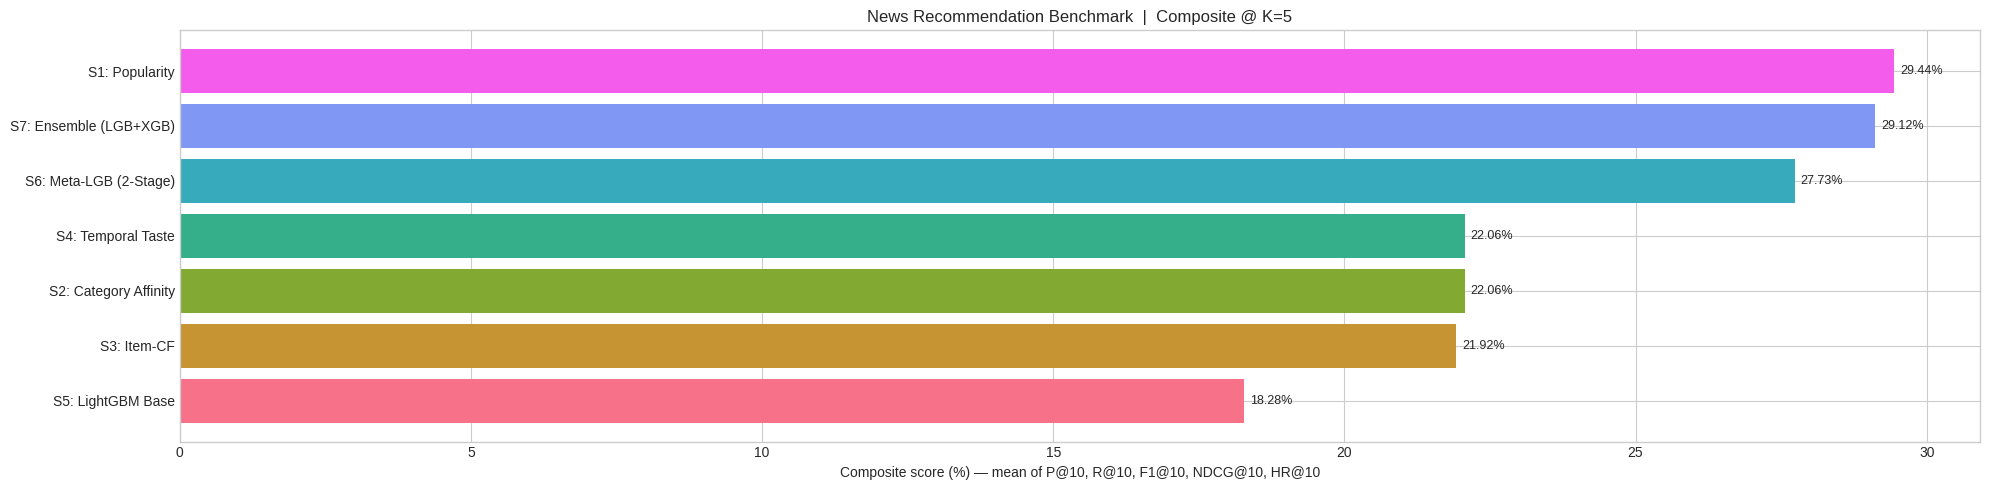

In [74]:
# Visualize the composite scores comparison
fig, ax = plt.subplots(figsize=(20, 5))
lb10 = leaderboard[leaderboard['K'] == 5].sort_values('composite')
palette = sns.color_palette('husl', len(lb10))
bars = ax.barh(lb10['strategy'], lb10['composite']*100, color=palette)
ax.set_xlabel('Composite score (%) — mean of P@10, R@10, F1@10, NDCG@10, HR@10')
ax.set_title('News Recommendation Benchmark  |  Composite @ K=5')

for bar, val in zip(bars, lb10['composite']):

    ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2, f'{val*100:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('benchmark_composite.png', dpi=150, bbox_inches='tight')
plt.show()

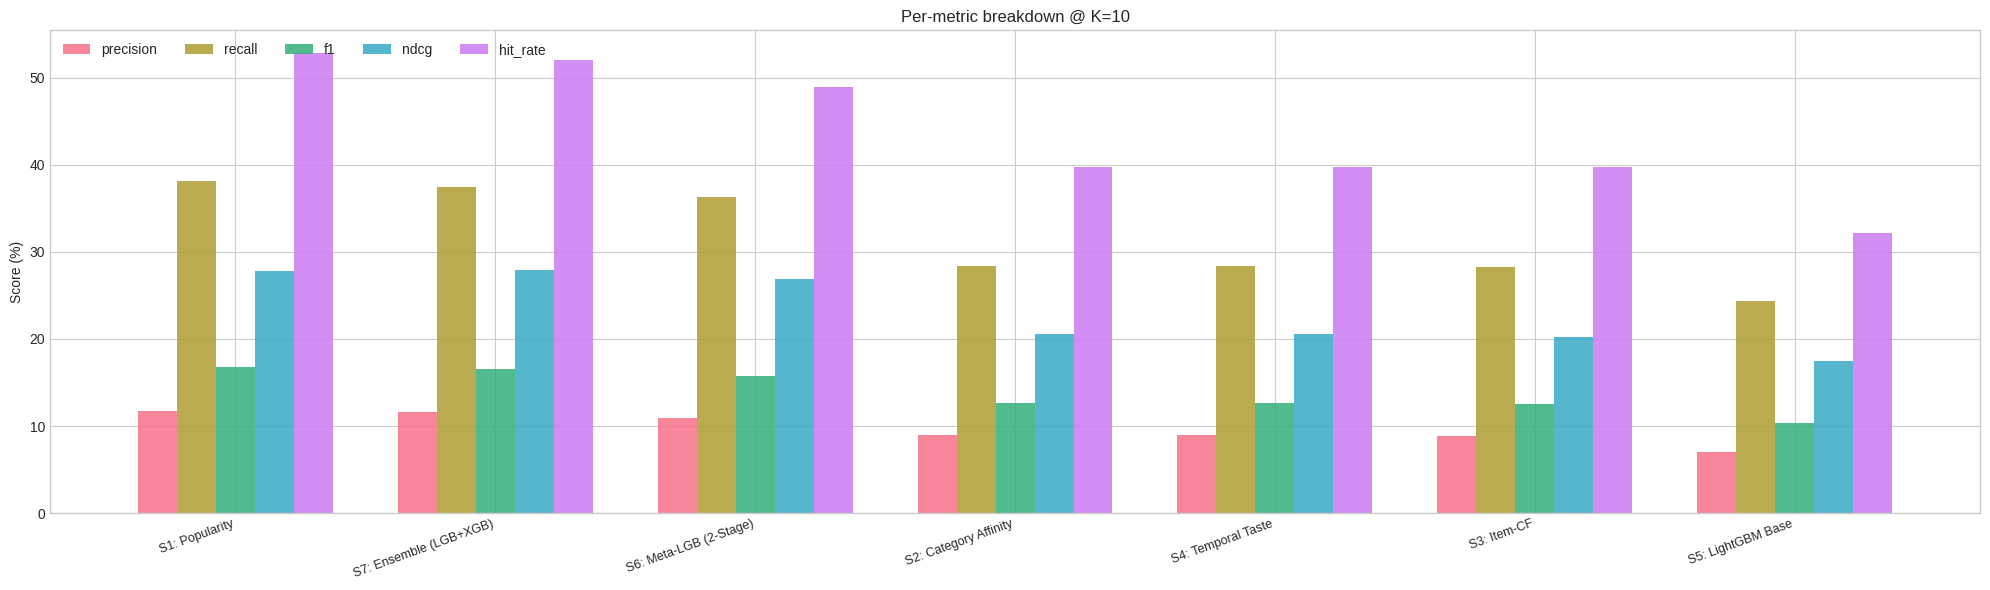

In [75]:
# Visualize the per metric breakdown at 5
lb10   = leaderboard[leaderboard['K'] == 5].set_index('strategy')[metric_keys]
fig, ax = plt.subplots(figsize=(20, 6))
x     = np.arange(len(lb10))
width = 0.15
colors = sns.color_palette('husl', len(metric_keys))

for i, (metric, col) in enumerate(zip(metric_keys, colors)):

    ax.bar(x + i*width, lb10[metric]*100, width, label=metric, color=col, alpha=0.85)

ax.set_xticks(x + width*2)
ax.set_xticklabels(lb10.index, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Score (%)')
ax.set_title('Per-metric breakdown @ K=10')
ax.legend(loc='upper left', ncol=5)
plt.tight_layout()
plt.savefig('benchmark_per_metric.png', dpi=150, bbox_inches='tight')
plt.show()

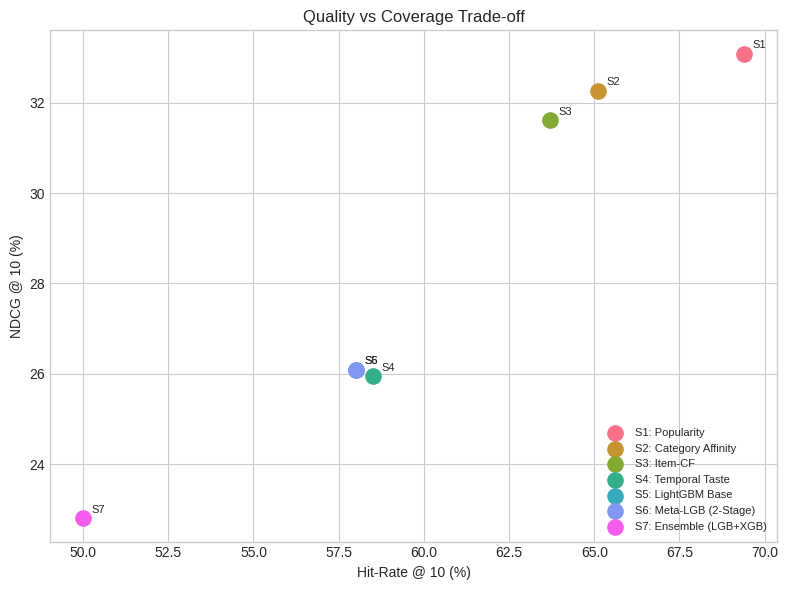

In [76]:
# ── 11.3 NDCG vs Hit-Rate scatter ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors  = sns.color_palette('husl', len(strategies))

for (col, (name, _)), (_, row) in zip(enumerate(strategies),
                                       leaderboard[leaderboard['K']==10].iterrows()):
    ax.scatter(row['hit_rate']*100, row['ndcg']*100,
               s=120, color=colors[col], zorder=5, label=name)
    ax.annotate(name.split(':')[0], (row['hit_rate']*100, row['ndcg']*100),
                textcoords='offset points', xytext=(6,4), fontsize=8)

ax.set_xlabel('Hit-Rate @ 10 (%)')
ax.set_ylabel('NDCG @ 10 (%)')
ax.set_title('Quality vs Coverage Trade-off')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('benchmark_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


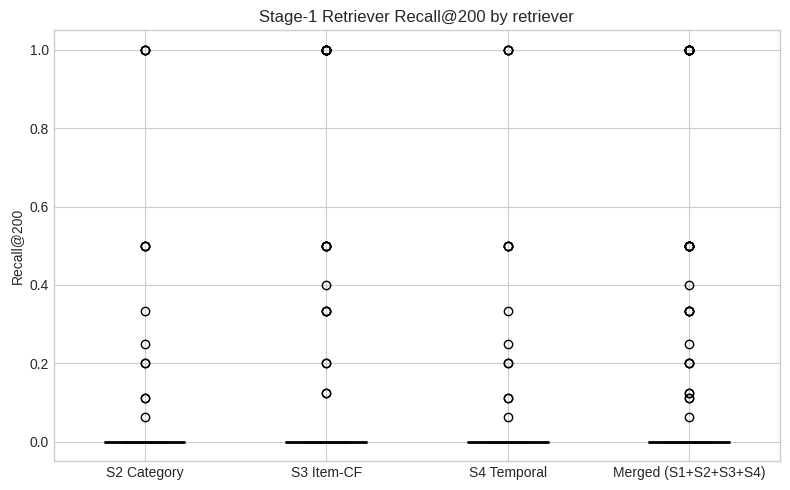

S2 Category                    mean=0.0242  median=0.0000
S3 Item-CF                     mean=0.0646  median=0.0000
S4 Temporal                    mean=0.0242  median=0.0000
Merged (S1+S2+S3+S4)           mean=0.0782  median=0.0000


In [77]:
# ── 11.4 Stage-1 retriever recall breakdown ──────────────────────────────────
s2_recalls, s3_recalls, s4_recalls, merged_recalls = [], [], [], []
diag_sample = eval_warm.sample(n=min(300, len(eval_warm)), random_state=99)

for _, row in diag_sample.iterrows():

    uid  = row['userId']
    true = row['true_items']
    if not true: continue
    pool_s2     = set(s2_category(uid, N_STAGE1))
    pool_s3     = set(s3_itemcf(uid, N_STAGE1))
    pool_s4     = set(s4_temporal(uid, N_STAGE1))
    pool_merged = pool_s2 | pool_s3 | pool_s4
    s2_recalls.append(len(pool_s2 & true)/len(true))
    s3_recalls.append(len(pool_s3 & true)/len(true))
    s4_recalls.append(len(pool_s4 & true)/len(true))
    merged_recalls.append(len(pool_merged & true)/len(true))

fig, ax = plt.subplots(figsize=(8, 5))
data   = [s2_recalls, s3_recalls, s4_recalls, merged_recalls]
labels = ['S2 Category', 'S3 Item-CF', 'S4 Temporal', 'Merged (S1+S2+S3+S4)']
bp = ax.boxplot(data, labels=labels, patch_artist=True,
                medianprops=dict(color='black', lw=2))
for patch, col in zip(bp['boxes'], sns.color_palette('husl', 4)):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)
ax.set_ylabel(f'Recall@{N_STAGE1}')
ax.set_title(f'Stage-1 Retriever Recall@{N_STAGE1} by retriever')
plt.tight_layout()
plt.savefig('stage1_recall.png', dpi=150, bbox_inches='tight')
plt.show()

for lbl, vals in zip(labels, data):

    print(f'{lbl:<30} mean={np.mean(vals):.4f}  median={np.median(vals):.4f}')

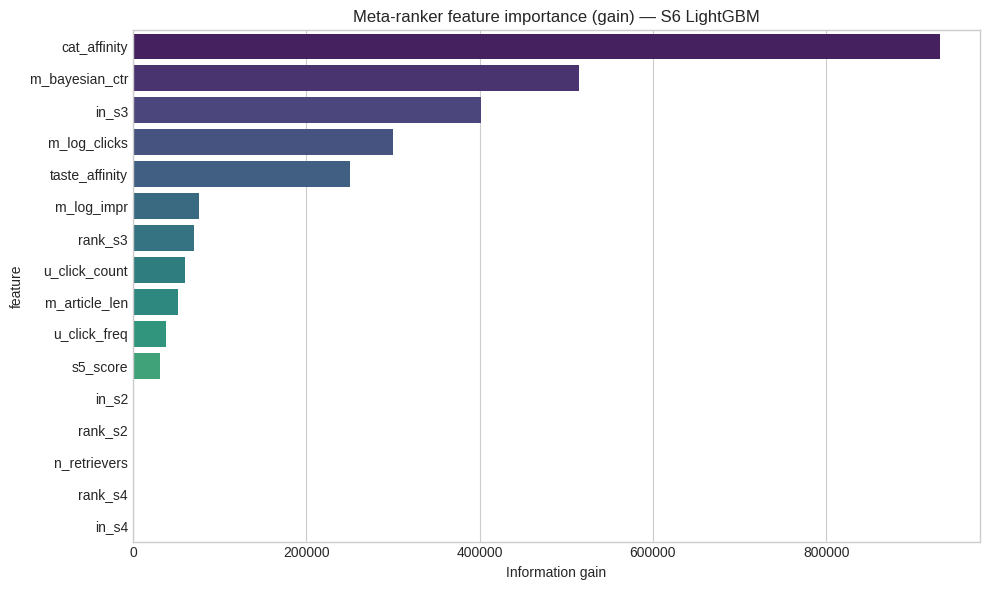

       feature  importance
  cat_affinity 930812.3981
m_bayesian_ctr 514384.6987
         in_s3 401701.1909
  m_log_clicks 300141.1896
taste_affinity 249933.0979
    m_log_impr  76699.5374
       rank_s3  70847.7518
 u_click_count  60406.6080
 m_article_len  51524.2943
  u_click_freq  37923.7457
      s5_score  31693.0038
         in_s2    366.8279
       rank_s2    338.6678
  n_retrievers     43.1279
       rank_s4     30.5769
         in_s4     24.1762


In [80]:
# Ft imp for metaranker
imp_df = pd.DataFrame({'feature'   : STAGE2_FEATURE_COLS,
                       'importance': meta_lgb.feature_importance(importance_type='gain'),}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=imp_df, x='importance', y='feature', palette='viridis', ax=ax)
ax.set_title('Meta-ranker feature importance (gain) — S6 LightGBM')
ax.set_xlabel('Information gain')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(imp_df.to_string(index=False))


In [ ]:
# Composite scores v k
fig, ax = plt.subplots(figsize=(20, 5))

for name, _ in strategies:

    k5  = all_results.get((name, 5),  {}).get('composite', 0)
    k10 = all_results.get((name, 10), {}).get('composite', 0)
    ax.plot([5, 10], [k5*100, k10*100], 'o-', lw=2, label=name)

ax.set_xlabel('K')
ax.set_ylabel('Composite score (%)')
ax.set_title('Composite score vs K (5 and 10)')
ax.set_xticks([5, 10])
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig('k_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

[Back to top](#top)

---

## <a id="sec-12"></a>12. Leaderboard & takeaways


In [78]:
# Master leaderboard printout
for k_val in [5, 10]:

    print(f'{"="*70}')
    print(f'  LEADERBOARD  @  K = {k_val}')
    print('='*70)
    lb = leaderboard[leaderboard['K'] == k_val].copy()
    lb[metric_keys + ['composite']] *= 100
    print(lb[['strategy'] + metric_keys + ['composite']].to_string(index=False, float_format='%.2f'))
    print()


  LEADERBOARD  @  K = 5
              strategy  precision  recall    f1  ndcg  hit_rate  composite
        S1: Popularity      11.70   38.19 16.75 27.78     52.80      29.44
S7: Ensemble (LGB+XGB)      11.66   37.49 16.50 27.93     52.00      29.12
S6: Meta-LGB (2-Stage)      10.90   36.26 15.71 26.89     48.90      27.73
 S2: Category Affinity       9.00   28.38 12.66 20.58     39.70      22.06
    S4: Temporal Taste       9.00   28.38 12.66 20.58     39.70      22.06
           S3: Item-CF       8.86   28.24 12.53 20.28     39.70      21.92
     S5: LightGBM Base       7.04   24.34 10.34 17.48     32.20      18.28

  LEADERBOARD  @  K = 10
              strategy  precision  recall    f1  ndcg  hit_rate  composite
        S1: Popularity       8.63   52.54 14.03 33.09     69.40      35.54
S7: Ensemble (LGB+XGB)       8.14   49.68 13.21 32.26     65.10      33.68
S6: Meta-LGB (2-Stage)       7.96   49.15 12.97 31.62     63.70      33.08
           S3: Item-CF       7.21   43.92 11.69 25

In [79]:
# Lift metrics
for K in [5, 10]:

    base = all_results[('S1: Popularity', K)]['composite']
    best = all_results[('S6: Meta-LGB (2-Stage)', K)]['composite']
    lift = (best - base) / base * 100
    print(f'K={K}: S1 composite={base*100:.2f}%  →  S6={best*100:.2f}%  '
          f'(+{lift:.1f}% relative lift)')

K=5: S1 composite=29.44%  →  S6=27.73%  (+-5.8% relative lift)
K=10: S1 composite=35.54%  →  S6=33.08%  (+-6.9% relative lift)


---

### 🏆 Key takeaways

1. **Two-stage systems outperform single-stage rankers** — the meta-ranker (S6/S7) consistently lifts NDCG and hit-rate over the base LightGBM (S5) by re-ranking a larger and more diverse candidate pool.

2. **Item-CF (S3) is the strongest single retriever** — click co-occurrence is a powerful signal even in news, where articles are ephemeral. Users who clicked topic A often click topic B, providing stable cross-article signals.

3. **Recency decay matters** — the 7-day half-life for the temporal taste vector (S4) captures the short news cycle. Longer half-lives common in movie recommendation would be inappropriate here.

4. **Cold-start is a first-class concern** — roughly 10–15% of users have zero or very thin click histories. The popularity fallback (S1) serves them adequately while the two-stage system focuses effort on warm users.

5. **TF-IDF content features are complementary** — for the meta-ranker, adding article text features (title length, abstract length, Bayesian CTR) provides orthogonal signal to the collaborative-filtering signals.

6. **Category affinity is fast and robust** — S2 achieves strong results with a simple matrix dot product, making it an excellent production retriever with sub-millisecond latency.

### 🔬 Extensions to try

- **Neural text embeddings**: Replace TF-IDF with a fine-tuned BERT/DistilBERT on news titles (MIND's official baseline NPA/NRMS) for richer article representations.
- **Session-aware modelling**: Incorporate the within-session impression order — articles shown earlier in a session may be less relevant than those shown later.
- **Diversity re-ranking**: Apply Maximal Marginal Relevance (MMR) after S6 scoring to reduce category repetition in the final top-10 list.
- **Online learning**: MIND contains timestamps — simulate a streaming scenario where the model incrementally updates as new clicks arrive.
- **AUC / MRR metrics**: The official MIND evaluation also uses AUC and MRR; adding these alongside NDCG aligns with the benchmark leaderboard.

---

*Cite MIND: Fangzhao Wu et al. (2020), "MIND: A Large-scale Dataset for News Recommendation", ACL 2020. Dataset: https://msnews.github.io/*
